# Mini Project Notebook: Credit Card Clustering

## Dr. Prashanth Kannadaguli
### Founding Chief Research Architect & President
### Dhaarini AI-Tech Research Academy, Bengaluru, India

In [1]:
# Load the required libraries
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy as sch
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 90
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Dataset Exploration



Load the dataset "CreditCards.csv" into a Pandas DataFrame. Display the first 15 rows and all columns.

In [2]:
#load dataset CreditCards.csv
# (In Colab, upload CreditCards.csv to the session storage first)
DATA_PATH = "CreditCards.csv" if os.path.exists("CreditCards.csv") else "/mnt/user-data/uploads/CreditCards.csv"
df = pd.read_csv(DATA_PATH)

pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.width", 250)
print("Shape:", df.shape)
df.head(15)

Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


Determine the data types of each column in the DataFrame. Check for missing values and count the number of missing values in each column.

In [3]:
# Data types and missing values
print("Data types:\n")
print(df.dtypes)
print("\nMissing values per column:\n")
print(df.isnull().sum())

Data types:

CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

Missing values per column:

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                       

Check the data types of all columns and ensure they are consistent with the expected types (e.g., numerical for quantities, categorical for identifiers).

In [4]:
# Check that every column has the type we expect
expected_numeric = [c for c in df.columns if c != "CUST_ID"]
type_check = pd.DataFrame({
    "dtype": df.dtypes,
    "expected": ["identifier (string)" if c == "CUST_ID" else "numeric" for c in df.columns],
    "is_numeric": [pd.api.types.is_numeric_dtype(df[c]) for c in df.columns],
})
print(type_check)
print("\nAll expected-numeric columns are numeric:", all(pd.api.types.is_numeric_dtype(df[c]) for c in expected_numeric))
print("CUST_ID is the only non-numeric column (an identifier, not a feature).")

                                    dtype             expected  is_numeric
CUST_ID                               str  identifier (string)       False
BALANCE                           float64              numeric        True
BALANCE_FREQUENCY                 float64              numeric        True
PURCHASES                         float64              numeric        True
ONEOFF_PURCHASES                  float64              numeric        True
INSTALLMENTS_PURCHASES            float64              numeric        True
CASH_ADVANCE                      float64              numeric        True
PURCHASES_FREQUENCY               float64              numeric        True
ONEOFF_PURCHASES_FREQUENCY        float64              numeric        True
PURCHASES_INSTALLMENTS_FREQUENCY  float64              numeric        True
CASH_ADVANCE_FREQUENCY            float64              numeric        True
CASH_ADVANCE_TRX                    int64              numeric        True
PURCHASES_TRX            

Convert data types if necessary (e.g., convert object columns to numeric if appropriate).

In [5]:
# Convert data types where it makes sense
df["CUST_ID"] = df["CUST_ID"].astype("string")      # identifier -> string
df["TENURE"] = df["TENURE"].astype(int)             # months, whole numbers
# every other column is already float64, so no further conversion is needed
for c in expected_numeric:
    df[c] = pd.to_numeric(df[c], errors="coerce")   # safety net: bad values would become NaN
print(df.dtypes)

CUST_ID                              string
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


Calculate summary statistics (mean, median, mode, standard deviation, min, max, quartiles) for numerical columns.

In [6]:
# Summary statistics for the numerical columns
num_cols = [c for c in df.columns if c != "CUST_ID"]
summary = df[num_cols].describe().T                      # count, mean, std, min, quartiles, max
summary["median"] = df[num_cols].median()
summary["mode"] = df[num_cols].mode().iloc[0]
summary["skew"] = df[num_cols].skew()
summary = summary[["count","mean","median","mode","std","min","25%","50%","75%","max","skew"]]
summary.round(3)

,count,mean,median,mode,std,min,25%,50%,75%,max,skew
BALANCE,8950.0,1564.475,873.385,0.000,2081.532,0.000,128.282,873.385,2054.140,19043.139,2.393
BALANCE_FREQUENCY,8950.0,0.877,1.000,1.000,0.237,0.000,0.889,1.000,1.000,1.000,-2.023
PURCHASES,8950.0,1003.205,361.280,0.000,2136.635,0.000,39.635,361.280,1110.130,49039.570,8.144
ONEOFF_PURCHASES,8950.0,592.437,38.000,0.000,1659.888,0.000,0.000,38.000,577.405,40761.250,10.045
INSTALLMENTS_PURCHASES,8950.0,411.068,89.000,0.000,904.338,0.000,0.000,89.000,468.638,22500.000,7.299
CASH_ADVANCE,8950.0,978.871,0.000,0.000,2097.164,0.000,0.000,0.000,1113.821,47137.212,5.167
PURCHASES_FREQUENCY,8950.0,0.490,0.500,1.000,0.401,0.000,0.083,0.500,0.917,1.000,0.060
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202,0.083,0.000,0.298,0.000,0.000,0.083,0.300,1.000,1.536
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364,0.167,0.000,0.397,0.000,0.000,0.167,0.750,1.000,0.509
CASH_ADVANCE_FREQUENCY,8950.0,0.135,0.000,0.000,0.200,0.000,0.000,0.000,0.222,1.500,1.829


Calculate the correlation between numerical variables. Visualize the correlation matrix using a heatmap.

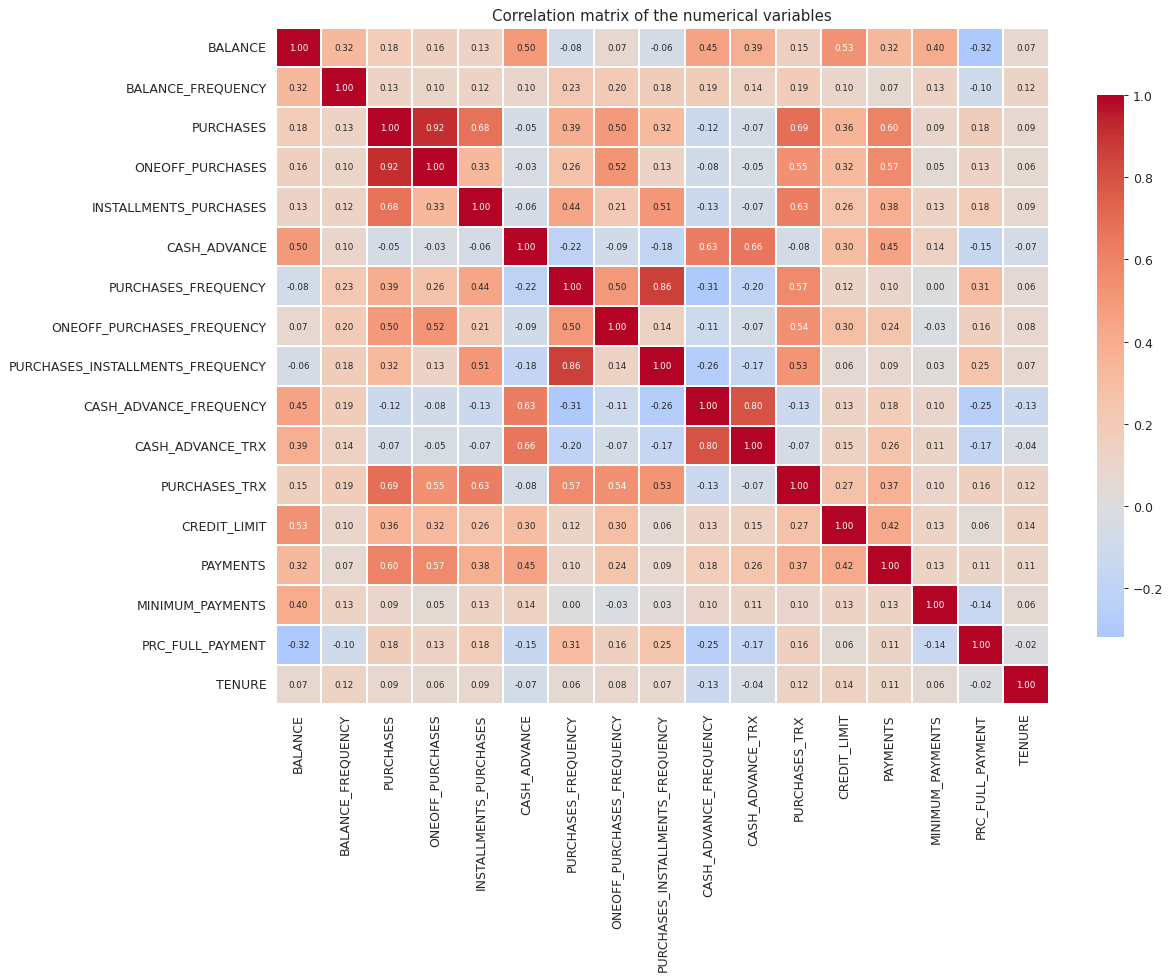

Top 10 correlated pairs:
PURCHASES               ONEOFF_PURCHASES                    0.917
PURCHASES_FREQUENCY     PURCHASES_INSTALLMENTS_FREQUENCY    0.863
CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX                    0.800
PURCHASES               PURCHASES_TRX                       0.690
                        INSTALLMENTS_PURCHASES              0.680
CASH_ADVANCE            CASH_ADVANCE_TRX                    0.656
                        CASH_ADVANCE_FREQUENCY              0.629
INSTALLMENTS_PURCHASES  PURCHASES_TRX                       0.628
PURCHASES               PAYMENTS                            0.603
PURCHASES_FREQUENCY     PURCHASES_TRX                       0.568
dtype: float64


In [7]:
# Correlation matrix + heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7},
            linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix of the numerical variables")
plt.tight_layout(); plt.show()

# strongest pairs
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().sort_values(key=abs, ascending=False)
print("Top 10 correlated pairs:")
print(pairs.head(10).round(3))

Analyze the distribution of categorical variables (e.g., count the occurrences of different values in the CUST_ID column).

In [8]:
# Distribution of categorical variables
# CUST_ID is a unique identifier, so every value should occur once.
print("Rows:", len(df), "| unique CUST_ID:", df["CUST_ID"].nunique())
print(df["CUST_ID"].value_counts().head())
print("Max occurrences of one CUST_ID:", df["CUST_ID"].value_counts().max(), "-> no information for clustering.")

# The dataset has no other genuine categorical column, so we derive meaningful ones
# from the numeric data (used later for group-by analysis and plots).
df["CREDIT_LIMIT_LEVEL"] = pd.qcut(df["CREDIT_LIMIT"], q=3, labels=["Low", "Medium", "High"])
df["PURCHASE_FREQ_LEVEL"] = pd.cut(df["PURCHASES_FREQUENCY"], bins=[-0.01, 0.33, 0.66, 1.0],
                                   labels=["Low", "Medium", "High"])
df["CASH_ADV_FREQ_LEVEL"] = pd.cut(df["CASH_ADVANCE_FREQUENCY"], bins=[-0.01, 0.0, 0.33, 10],
                                   labels=["None", "Occasional", "Frequent"])
df["TENURE_GROUP"] = pd.cut(df["TENURE"], bins=[0, 11, 12], labels=["< 12 months", "12 months"])
cat_cols = ["CREDIT_LIMIT_LEVEL", "PURCHASE_FREQ_LEVEL", "CASH_ADV_FREQ_LEVEL", "TENURE_GROUP"]
for c in cat_cols:
    print(f"\n{c}\n", df[c].value_counts(dropna=False))

Rows: 8950 | unique CUST_ID: 8950
CUST_ID
C10001    1
C10002    1
C10003    1
C10004    1
C10005    1
Name: count, dtype: Int64
Max occurrences of one CUST_ID: 1 -> no information for clustering.

CREDIT_LIMIT_LEVEL
 CREDIT_LIMIT_LEVEL
Medium    3061
Low       2990
High      2898
NaN          1
Name: count, dtype: int64

PURCHASE_FREQ_LEVEL
 PURCHASE_FREQ_LEVEL
High      3752
Low       3690
Medium    1508
Name: count, dtype: int64

CASH_ADV_FREQ_LEVEL
 CASH_ADV_FREQ_LEVEL
None          4628
Occasional    2764
Frequent      1558
Name: count, dtype: int64

TENURE_GROUP
 TENURE_GROUP
12 months      7584
< 12 months    1366
Name: count, dtype: int64


Identify outliers using box plots or statistical methods (e.g., IQR).

                                    lower     upper  n_outliers    pct
column                                                                
BALANCE_FREQUENCY                    0.72      1.17        1493  16.68
PRC_FULL_PAYMENT                    -0.21      0.36        1474  16.47
TENURE                              12.00     12.00        1366  15.26
CASH_ADVANCE                     -1670.73   2784.55        1030  11.51
ONEOFF_PURCHASES                  -866.11   1443.51        1013  11.32
INSTALLMENTS_PURCHASES            -702.96   1171.59         867   9.69
MINIMUM_PAYMENTS                  -815.42   1810.03         841   9.40
PAYMENTS                         -1893.51   4177.92         808   9.03
PURCHASES                        -1566.11   2715.87         808   9.03
CASH_ADVANCE_TRX                    -6.00     10.00         804   8.98
ONEOFF_PURCHASES_FREQUENCY          -0.45      0.75         782   8.74
PURCHASES_TRX                      -23.00     41.00         766   8.56
BALANC

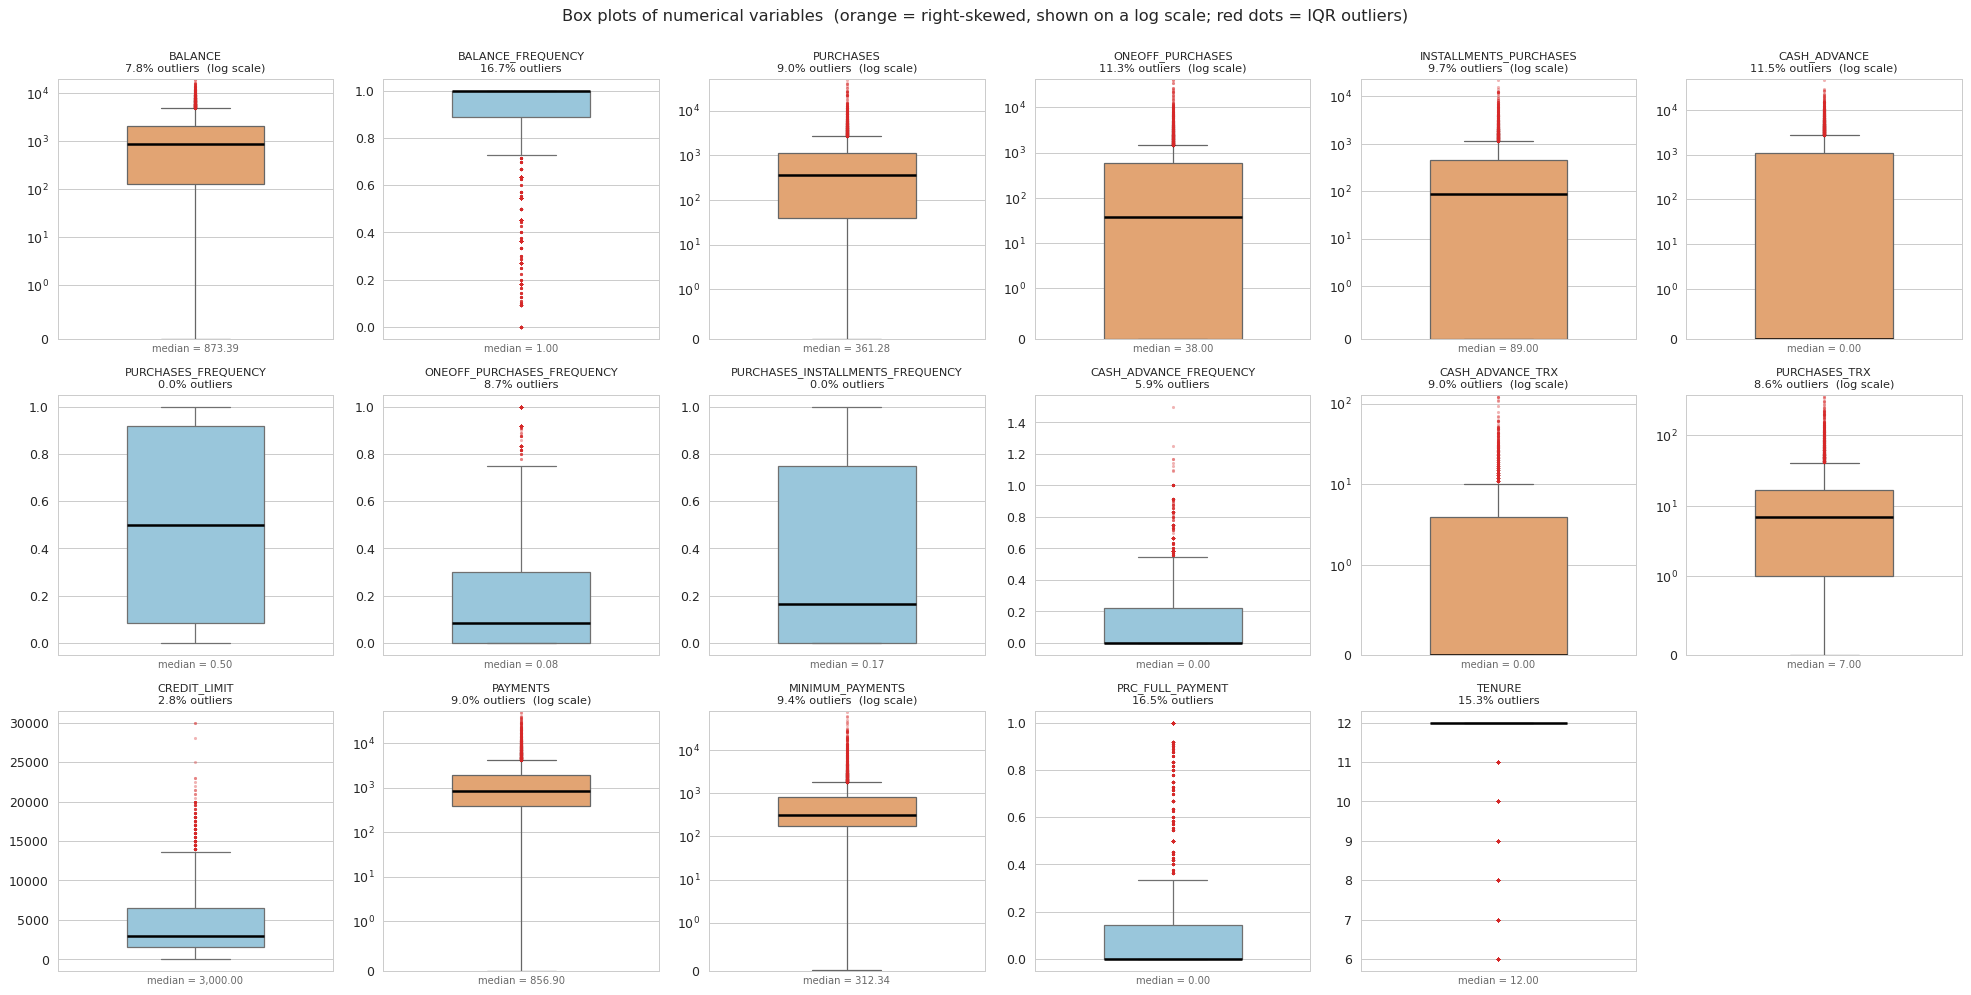

In [9]:
# Identify outliers with the IQR rule and box plots
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

out_summary = []
for c in num_cols:
    lo, hi = iqr_bounds(df[c].dropna())
    n = int(((df[c] < lo) | (df[c] > hi)).sum())
    out_summary.append((c, lo, hi, n, 100 * n / len(df)))
out_summary = pd.DataFrame(out_summary, columns=["column", "lower", "upper", "n_outliers", "pct"]).set_index("column")
print(out_summary.round(2).sort_values("pct", ascending=False))

# Heavily skewed columns are drawn on a symmetric-log axis, otherwise the box is squashed flat against 0
skewed = [c for c in num_cols if df[c].skew() > 2]
fig, axes = plt.subplots(3, 6, figsize=(22, 11))
for ax, c in zip(axes.ravel(), num_cols):
    is_skewed = c in skewed
    sns.boxplot(y=df[c], ax=ax, width=0.5,
                color="#f4a261" if is_skewed else "#8ecae6",
                flierprops=dict(marker="o", markersize=2.5, markerfacecolor="#d62828", markeredgecolor="none", alpha=0.35),
                medianprops=dict(color="black", linewidth=2))
    if is_skewed:
        ax.set_yscale("symlog", linthresh=1)   # linear between 0 and 1, log above
        ax.set_ylim(bottom=0)                  # these values can never be negative
    pct = out_summary.loc[c, "pct"]
    ax.set_title(f"{c}\n{pct:.1f}% outliers" + ("  (log scale)" if is_skewed else ""), fontsize=9)
    ax.set_ylabel(""); ax.set_xticks([])
    ax.text(0.5, -0.02, f"median = {df[c].median():,.2f}", transform=ax.transAxes, ha="center", va="top", fontsize=8, color="dimgray")
for ax in axes.ravel()[len(num_cols):]:
    ax.axis("off")
plt.suptitle("Box plots of numerical variables  (orange = right-skewed, shown on a log scale; red dots = IQR outliers)", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

Visualize the impact of outliers: Remove outliers and re-visualize the data to assess their impact on the overall distribution and relationships.

Rows before: 8950  | after removing extreme outliers: 7681  (14.2% removed)


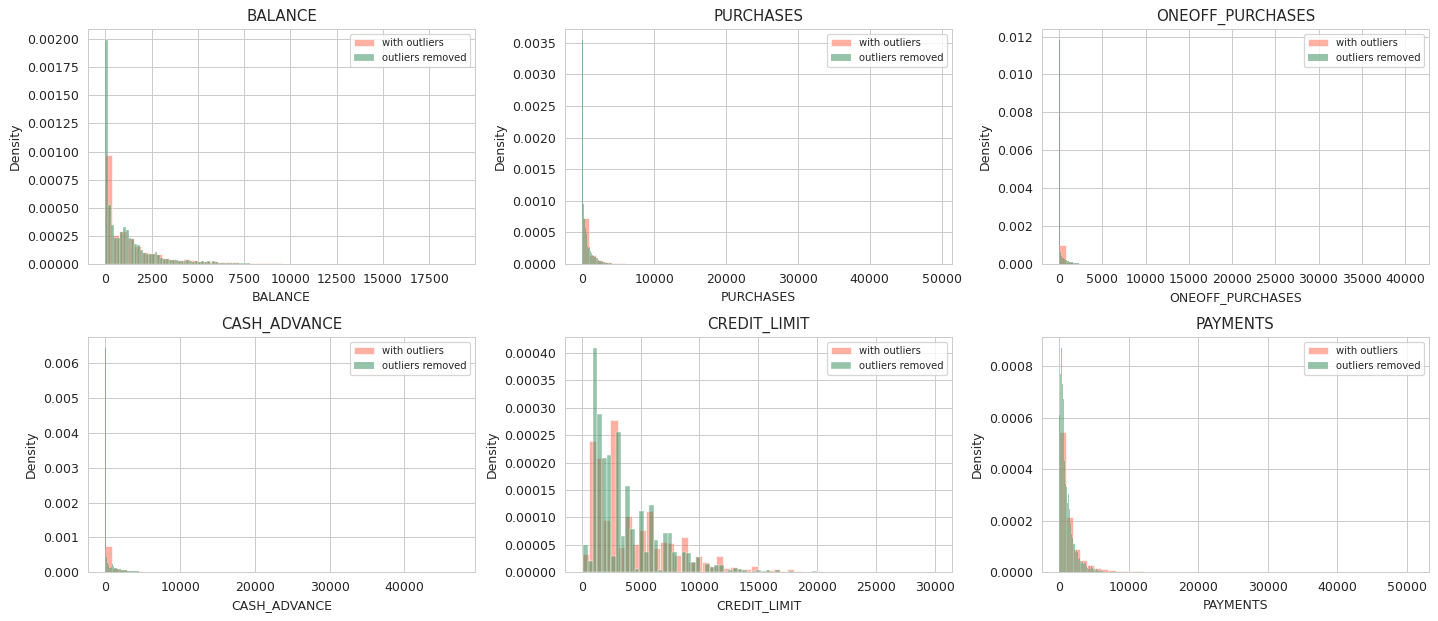

                  skew_before  skew_after  std_before  std_after
BALANCE                  2.39        1.85     2081.53    1457.02
PURCHASES                8.14        1.79     2136.63     765.99
ONEOFF_PURCHASES        10.05        1.95     1659.89     491.51
CASH_ADVANCE             5.17        1.92     2097.16     987.61
CREDIT_LIMIT             1.52        1.57     3638.82    2989.99
PAYMENTS                 5.91        1.90     2895.06    1049.09

Corr(BALANCE, CREDIT_LIMIT): before = 0.531, after = 0.343
Corr(PURCHASES, ONEOFF_PURCHASES): before = 0.917, after = 0.744


In [10]:
# Impact of outliers: remove them (extreme ones, 3 x IQR) and compare
key_cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]
mask = pd.Series(True, index=df.index)
for c in key_cols:
    lo, hi = iqr_bounds(df[c].dropna(), k=3)
    mask &= df[c].isna() | ((df[c] >= lo) & (df[c] <= hi))
df_no_out = df[mask]
print(f"Rows before: {len(df)}  | after removing extreme outliers: {len(df_no_out)}  "
      f"({100*(1-len(df_no_out)/len(df)):.1f}% removed)")

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, c in zip(axes.ravel(), key_cols):
    sns.histplot(df[c], bins=50, color="tomato", alpha=0.5, label="with outliers", ax=ax, stat="density")
    sns.histplot(df_no_out[c], bins=50, color="seagreen", alpha=0.5, label="outliers removed", ax=ax, stat="density")
    ax.set_title(c); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

comp = pd.DataFrame({"skew_before": df[key_cols].skew(), "skew_after": df_no_out[key_cols].skew(),
                     "std_before": df[key_cols].std(), "std_after": df_no_out[key_cols].std()})
print(comp.round(2))

# effect on relationships
print("\nCorr(BALANCE, CREDIT_LIMIT): before = %.3f, after = %.3f" %
      (df["BALANCE"].corr(df["CREDIT_LIMIT"]), df_no_out["BALANCE"].corr(df_no_out["CREDIT_LIMIT"])))
print("Corr(PURCHASES, ONEOFF_PURCHASES): before = %.3f, after = %.3f" %
      (df["PURCHASES"].corr(df["ONEOFF_PURCHASES"]), df_no_out["PURCHASES"].corr(df_no_out["ONEOFF_PURCHASES"])))

Identify missing values in the dataset and calculate the percentage of missing data for each column.

                    missing  pct_missing
CREDIT_LIMIT              1        0.011
MINIMUM_PAYMENTS        313        3.497
CREDIT_LIMIT_LEVEL        1        0.011


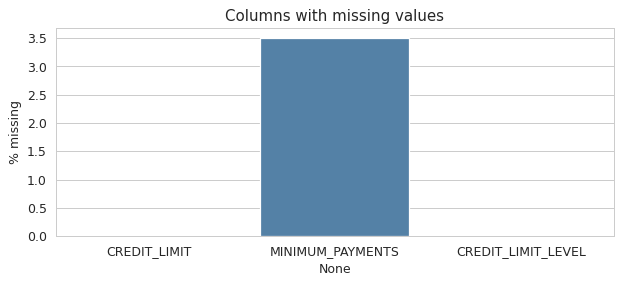

In [ ]:
# Missing values: count and percentage
plot_df = missing[missing.missing > 0]
plt.figure(figsize=(8, 3))
ax = sns.barplot(x=plot_df.index, y=plot_df["pct_missing"], color="steelblue")
ax.bar_label(ax.containers[0], fmt="%.3f%%")   # shows the value on each bar, even tiny ones
ax.set_xlabel("")
plt.ylabel("% missing"); plt.title("Columns with missing values"); plt.show()

Handle missing values (e.g., imputation, deletion) and outliers (e.g., capping, removal).

In [12]:
# Handle missing values and outliers -> df_clean
df_clean = df.copy()

# Missing values: both columns are right-skewed, so use the median (robust to outliers)
for c in ["MINIMUM_PAYMENTS", "CREDIT_LIMIT"]:
    med = df_clean[c].median()
    df_clean[c] = df_clean[c].fillna(med)
    print(f"{c}: filled with median = {med:.2f}")

# Outliers: cap (winsorise) at the 1st / 99th percentile instead of deleting rows,
# because for customer segmentation every customer should keep a segment.
cap_cols = [c for c in num_cols if c not in ["TENURE"]]
for c in cap_cols:
    lo, hi = df_clean[c].quantile([0.01, 0.99])
    df_clean[c] = df_clean[c].clip(lo, hi)

print("\nMissing values left:", int(df_clean[num_cols].isnull().sum().sum()))
print("Rows kept:", len(df_clean))
df_clean[num_cols].describe().T[["min", "mean", "max"]].round(2)

MINIMUM_PAYMENTS: filled with median = 312.34
CREDIT_LIMIT: filled with median = 3000.00

Missing values left: 0
Rows kept: 8950


,min,mean,max
BALANCE,0.07,1541.05,9338.80
BALANCE_FREQUENCY,0.09,0.88,1.00
PURCHASES,0.00,936.23,8977.29
ONEOFF_PURCHASES,0.00,536.49,6689.90
INSTALLMENTS_PURCHASES,0.00,384.50,3886.24
CASH_ADVANCE,0.00,935.92,9588.16
PURCHASES_FREQUENCY,0.00,0.49,1.00
ONEOFF_PURCHASES_FREQUENCY,0.00,0.20,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,0.00,0.36,1.00
CASH_ADVANCE_FREQUENCY,0.00,0.13,0.83


For categorical columns, impute missing values with the most frequent category or a new category.

In [13]:
# Categorical columns: impute with the most frequent category (or a new "Unknown" category)
print("Missing before:\n", df_clean[cat_cols].isnull().sum())
for c in cat_cols:
    if df_clean[c].isnull().any():
        df_clean[c] = df_clean[c].cat.add_categories("Unknown").fillna(df_clean[c].mode()[0])
# The derived categories are rebuilt from the cleaned numbers so they stay consistent
df_clean["CREDIT_LIMIT_LEVEL"] = pd.qcut(df_clean["CREDIT_LIMIT"], q=3, labels=["Low", "Medium", "High"])
print("\nMissing after:\n", df_clean[cat_cols].isnull().sum())

Missing before:
 CREDIT_LIMIT_LEVEL     1
PURCHASE_FREQ_LEVEL    0
CASH_ADV_FREQ_LEVEL    0
TENURE_GROUP           0
dtype: int64

Missing after:
 CREDIT_LIMIT_LEVEL     0
PURCHASE_FREQ_LEVEL    0
CASH_ADV_FREQ_LEVEL    0
TENURE_GROUP           0
dtype: int64


Explore the relationship between categorical variables and numerical variables (e.g., calculate the average BALANCE for different CUST_ID categories).

Average BALANCE per CUST_ID category (first 3):
CUST_ID
C10001      40.900749
C10002    3202.467416
C10003    2495.148862
Name: BALANCE, dtype: float64

=== Average values by CREDIT_LIMIT_LEVEL ===
                    BALANCE  PURCHASES  CASH_ADVANCE  PAYMENTS
CREDIT_LIMIT_LEVEL                                            
Low                   655.1      441.6         348.2     786.6
Medium               1204.2      795.0         813.6    1401.5
High                 2811.0     1595.8        1671.6    2801.6

=== Average values by PURCHASE_FREQ_LEVEL ===
                     BALANCE  PURCHASES  CASH_ADVANCE  PAYMENTS
PURCHASE_FREQ_LEVEL                                            
Low                   1762.0      166.0        1439.3    1428.2
Medium                1318.0      763.2         678.9    1330.8
High                  1413.4     1763.2         544.2    1995.1

=== Average values by CASH_ADV_FREQ_LEVEL ===
                     BALANCE  PURCHASES  CASH_ADVANCE  PAYMENTS
CASH_ADV_

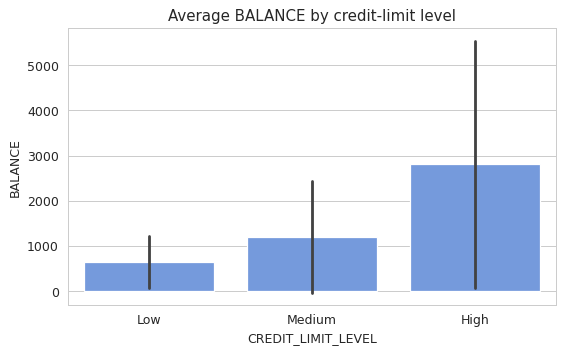

In [14]:
# Categorical vs numerical
# Grouping by CUST_ID is meaningless (each ID occurs once -> its "average" is just the row value),
# so we use the derived categories instead.
print("Average BALANCE per CUST_ID category (first 3):")
print(df_clean.groupby("CUST_ID")["BALANCE"].mean().head(3))

for cat in ["CREDIT_LIMIT_LEVEL", "PURCHASE_FREQ_LEVEL", "CASH_ADV_FREQ_LEVEL"]:
    print(f"\n=== Average values by {cat} ===")
    print(df_clean.groupby(cat, observed=True)[["BALANCE", "PURCHASES", "CASH_ADVANCE", "PAYMENTS"]].mean().round(1))

plt.figure(figsize=(7, 4))
sns.barplot(data=df_clean, x="CREDIT_LIMIT_LEVEL", y="BALANCE", order=["Low", "Medium", "High"], errorbar="sd", color="cornflowerblue")
plt.title("Average BALANCE by credit-limit level"); plt.show()

Analyze the distribution of categorical variables conditioned on other categorical variables (e.g., how many customers with a high credit limit also have a high purchase frequency?).

Counts:
 PURCHASE_FREQ_LEVEL   Low  Medium  High
CREDIT_LIMIT_LEVEL                     
Low                  1354     506  1130
Medium               1298     555  1209
High                 1038     447  1413

Row % (purchase frequency level given credit limit level):
 PURCHASE_FREQ_LEVEL   Low  Medium  High
CREDIT_LIMIT_LEVEL                     
Low                  45.3    16.9  37.8
Medium               42.4    18.1  39.5
High                 35.8    15.4  48.8

Customers with a HIGH credit limit AND HIGH purchase frequency: 1413 (15.8% of all customers, 48.8% of high-limit customers)
Chi-square test of independence: chi2=88.8, p=2.4e-18


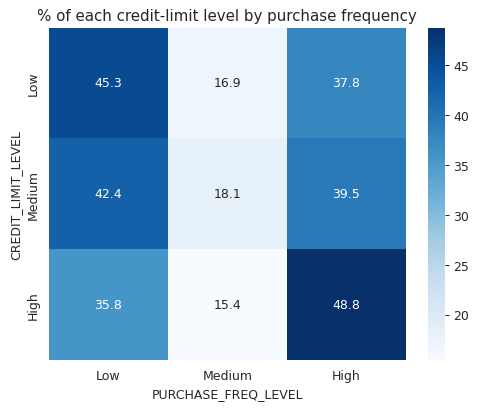

In [15]:
# Categorical conditioned on categorical
ct = pd.crosstab(df_clean["CREDIT_LIMIT_LEVEL"], df_clean["PURCHASE_FREQ_LEVEL"])
print("Counts:\n", ct)
ct_pct = pd.crosstab(df_clean["CREDIT_LIMIT_LEVEL"], df_clean["PURCHASE_FREQ_LEVEL"], normalize="index") * 100
print("\nRow % (purchase frequency level given credit limit level):\n", ct_pct.round(1))
hi = ct.loc["High", "High"]
print(f"\nCustomers with a HIGH credit limit AND HIGH purchase frequency: {hi} "
      f"({100*hi/len(df_clean):.1f}% of all customers, {ct_pct.loc['High','High']:.1f}% of high-limit customers)")

chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"Chi-square test of independence: chi2={chi2:.1f}, p={p:.3g}")
sns.heatmap(ct_pct, annot=True, fmt=".1f", cmap="Blues"); plt.title("% of each credit-limit level by purchase frequency"); plt.show()

Explore the relationship between categorical variables and time-based features (e.g., how does the average purchase amount change over time for different customer segments?).

CREDIT_LIMIT_LEVEL   Low  Medium   High
TENURE                                 
6                   53.3    51.6  192.4
7                   61.2    66.9  134.6
8                   61.7   107.6   84.9
9                   75.4    99.0  117.9
10                  83.6    85.7  147.7
11                  48.1    99.2  148.8
12                  77.0   139.4  278.8


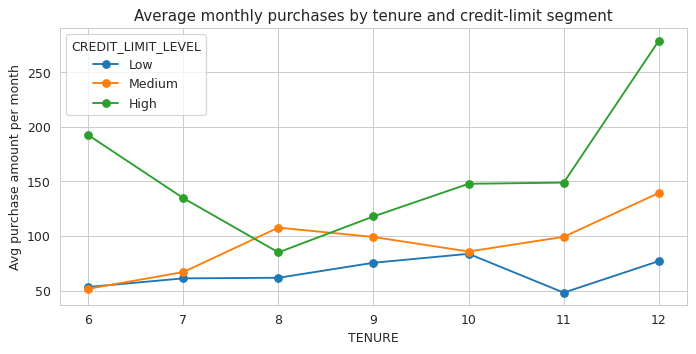

In [16]:
# Categorical variables vs "time" features
# The data is a single snapshot (no dates). The only time-related field is TENURE
# (months as a customer), and purchases cover the last 6 months. We use TENURE as the time axis.
df_clean["PURCHASES_PER_MONTH"] = df_clean["PURCHASES"] / 6
by_tenure = df_clean.groupby(["TENURE", "CREDIT_LIMIT_LEVEL"], observed=True)["PURCHASES_PER_MONTH"].mean().unstack()
print(by_tenure.round(1))

by_tenure.plot(marker="o", figsize=(9, 4))
plt.ylabel("Avg purchase amount per month"); plt.title("Average monthly purchases by tenure and credit-limit segment")
plt.show()

Identify any patterns or trends in the data that might be relevant for customer segmentation (e.g., are there specific groups of customers with similar purchasing behaviors?).

BEHAVIOUR_GROUP
Revolvers (carry a balance)    4381
Cash-advance heavy             3491
Full payers (transactors)      1074
Inactive                          4
Name: count, dtype: int64

                             BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  PRC_FULL_PAYMENT
BEHAVIOUR_GROUP                                                                                        
Cash-advance heavy           2425.56     264.52       2237.79       4498.92   1878.61              0.04
Full payers (transactors)     191.98    1763.25         30.97       5103.82   1955.68              0.86
Inactive                       98.67       0.06          0.00       4375.00     85.81              0.00
Revolvers (carry a balance)  1168.26    1269.59        121.23       4300.35   1393.14              0.07


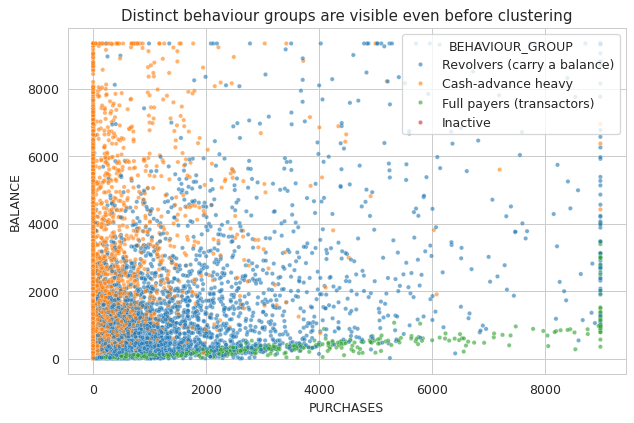

In [17]:
# Patterns relevant for segmentation: simple behavioural groups
def behaviour(r):
    if r["PURCHASES"] < 1 and r["CASH_ADVANCE"] < 1:
        return "Inactive"
    if r["CASH_ADVANCE"] > r["PURCHASES"]:
        return "Cash-advance heavy"
    if r["PRC_FULL_PAYMENT"] > 0.5:
        return "Full payers (transactors)"
    return "Revolvers (carry a balance)"
df_clean["BEHAVIOUR_GROUP"] = df_clean.apply(behaviour, axis=1)
print(df_clean["BEHAVIOUR_GROUP"].value_counts())
prof = df_clean.groupby("BEHAVIOUR_GROUP")[["BALANCE","PURCHASES","CASH_ADVANCE","CREDIT_LIMIT","PAYMENTS","PRC_FULL_PAYMENT"]].mean().round(2)
print(); print(prof)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="PURCHASES", y="BALANCE", hue="BEHAVIOUR_GROUP", s=12, alpha=0.6)
plt.title("Distinct behaviour groups are visible even before clustering"); plt.show()

Visualize the distribution of numerical variables using histograms or box plots to identify outliers or skewness in the data.

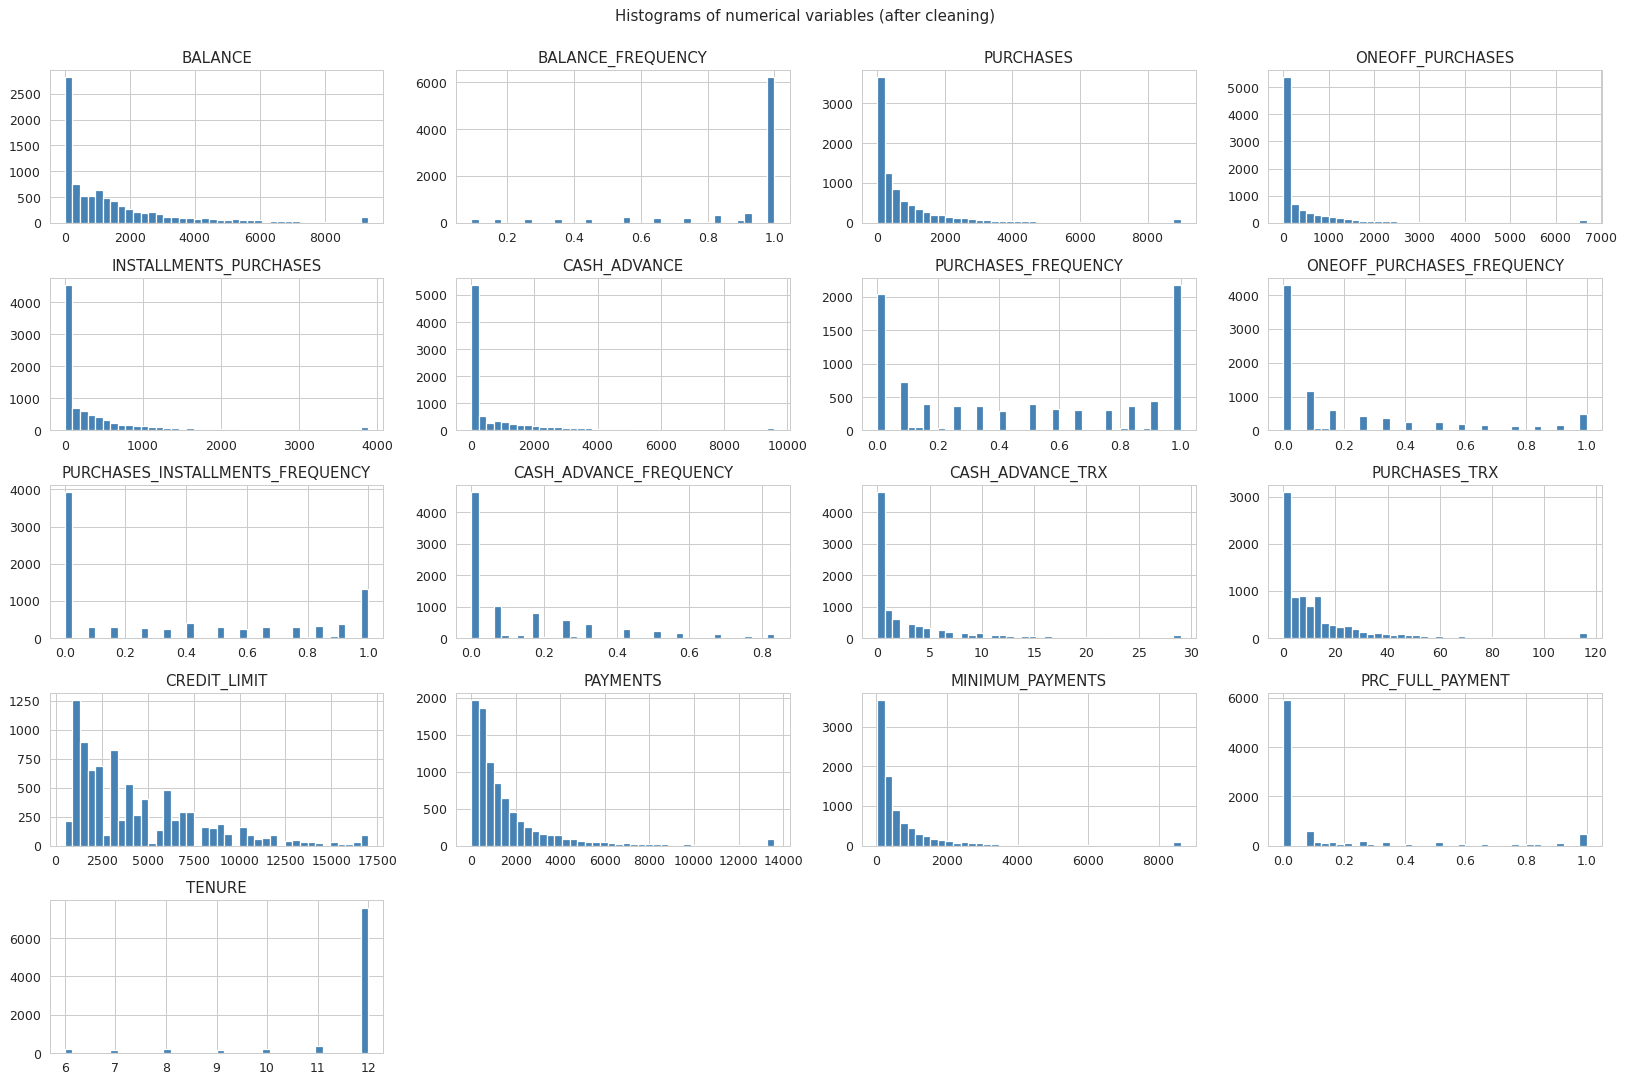

Skewness (|skew| > 1 = strongly skewed):
MINIMUM_PAYMENTS                    4.13
ONEOFF_PURCHASES                    3.35
PAYMENTS                            3.00
PURCHASES                           2.99
INSTALLMENTS_PURCHASES              2.87
CASH_ADVANCE                        2.72
PURCHASES_TRX                       2.68
CASH_ADVANCE_TRX                    2.61
PRC_FULL_PAYMENT                    1.94
BALANCE                             1.93
CASH_ADVANCE_FREQUENCY              1.68
ONEOFF_PURCHASES_FREQUENCY          1.54
CREDIT_LIMIT                        1.33
PURCHASES_INSTALLMENTS_FREQUENCY    0.51
PURCHASES_FREQUENCY                 0.06
BALANCE_FREQUENCY                  -1.98
TENURE                             -2.94
dtype: float64


In [18]:
# Histograms (distribution & skewness) of all numerical variables
df_clean[num_cols].hist(bins=40, figsize=(18, 12), color="steelblue", edgecolor="white")
plt.suptitle("Histograms of numerical variables (after cleaning)", y=1.0); plt.tight_layout(); plt.show()
print("Skewness (|skew| > 1 = strongly skewed):")
print(df_clean[num_cols].skew().sort_values(ascending=False).round(2))

## EDA

Visualize the distribution of numerical variables: Create histograms, box plots, and density plots to understand the shape, central tendency, and spread of variables like BALANCE, PURCHASES, and ONEOFF_PURCHASES.

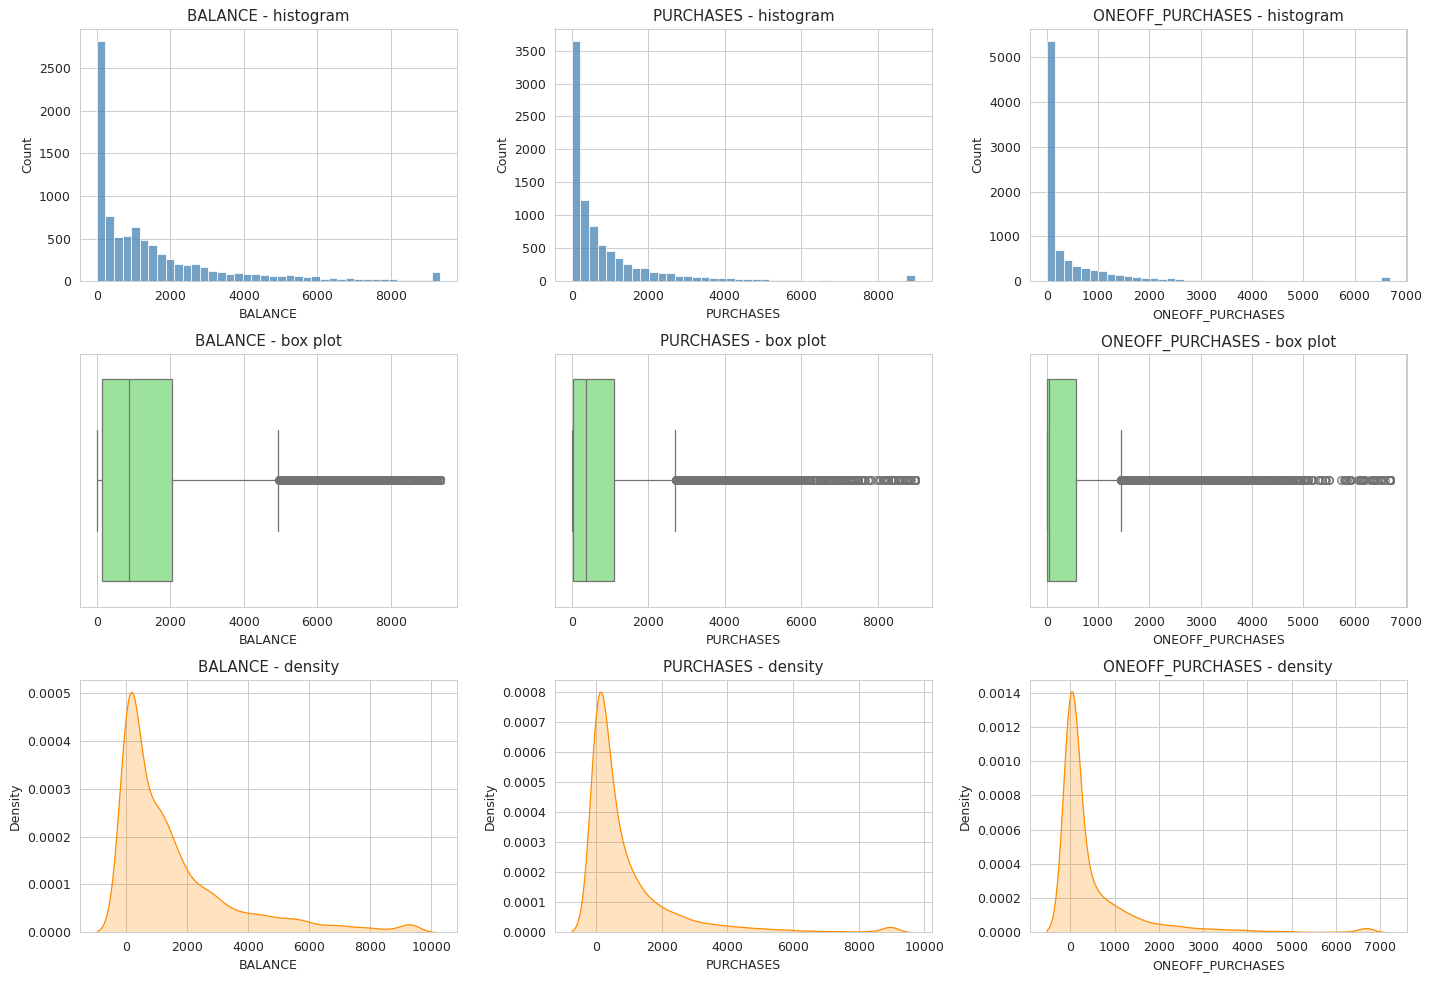

        BALANCE  PURCHASES  ONEOFF_PURCHASES
mean    1541.05     936.23            536.49
median   873.39     361.28             38.00
std     1966.60    1525.19           1096.91
skew       1.93       2.99              3.35


In [19]:
# Distribution of BALANCE, PURCHASES, ONEOFF_PURCHASES: histogram, box plot, density plot
cols3 = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES"]
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for j, c in enumerate(cols3):
    sns.histplot(df_clean[c], bins=40, ax=axes[0, j], color="steelblue"); axes[0, j].set_title(f"{c} - histogram")
    sns.boxplot(x=df_clean[c], ax=axes[1, j], color="lightgreen");      axes[1, j].set_title(f"{c} - box plot")
    sns.kdeplot(df_clean[c], ax=axes[2, j], fill=True, color="darkorange"); axes[2, j].set_title(f"{c} - density")
plt.tight_layout(); plt.show()
print(df_clean[cols3].agg(["mean", "median", "std", "skew"]).round(2))

Visualize the distribution of categorical variables: Create bar charts or pie charts to show the frequency of different categories in variables like CUST_ID, PURCHASES_FREQUENCY, and CASHADVANCEFREQUENCY.

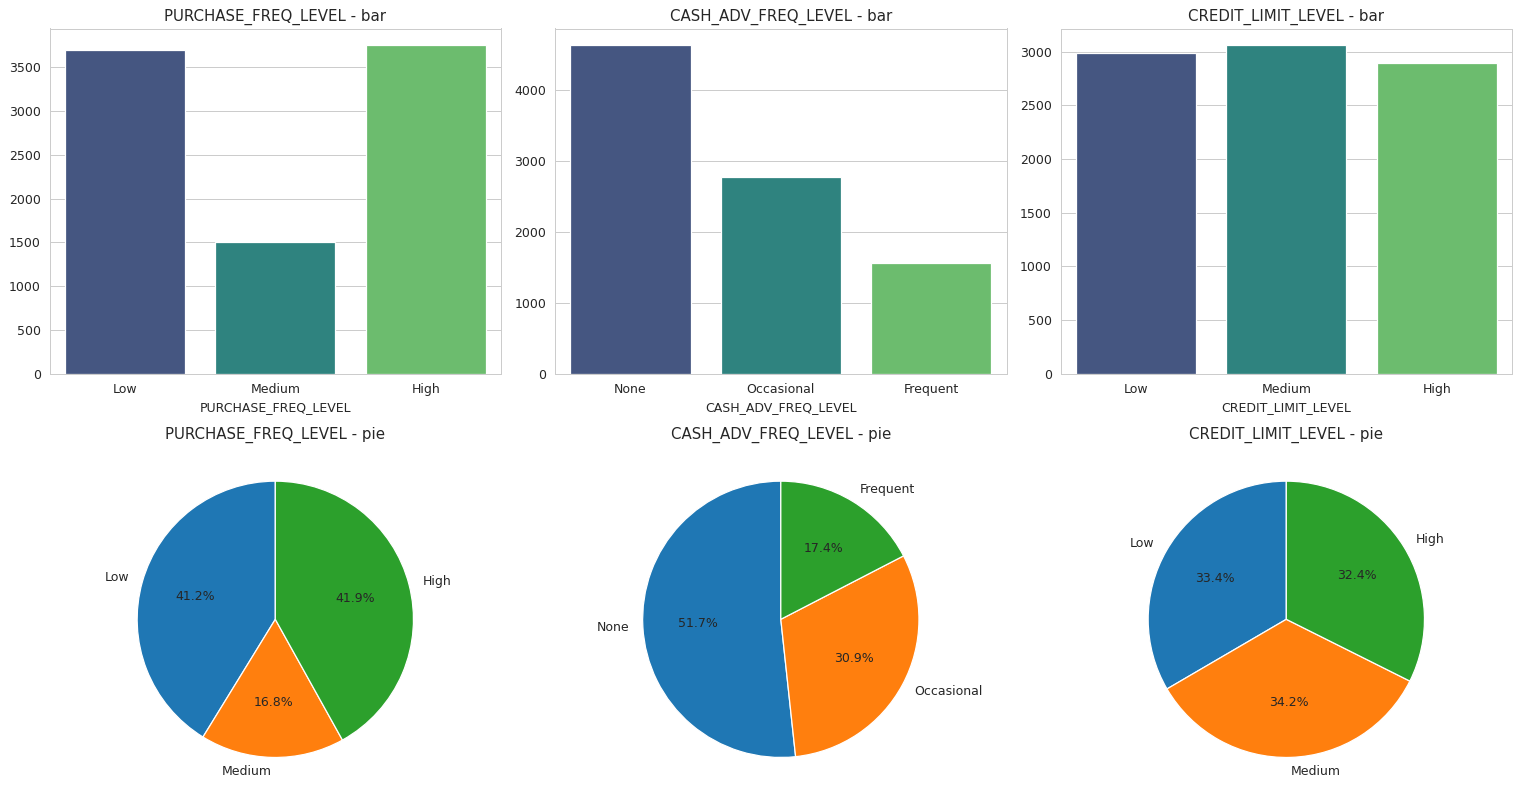

In [20]:
# Bar / pie charts for categorical variables
# CUST_ID is unique (a bar chart would have 8,950 bars of height 1), so we plot the
# categorised versions of the frequency variables created earlier instead.
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for j, c in enumerate(["PURCHASE_FREQ_LEVEL", "CASH_ADV_FREQ_LEVEL", "CREDIT_LIMIT_LEVEL"]):
    vc = df_clean[c].value_counts().sort_index()
    sns.barplot(x=vc.index.astype(str), y=vc.values, ax=axes[0, j], palette="viridis"); axes[0, j].set_title(c + " - bar")
    axes[1, j].pie(vc.values, labels=vc.index.astype(str), autopct="%1.1f%%", startangle=90); axes[1, j].set_title(c + " - pie")
plt.tight_layout(); plt.show()

Visualize the relationship between numerical variables: Create scatter plots to examine the correlation between pairs of numerical variables, such as BALANCE and PURCHASES.

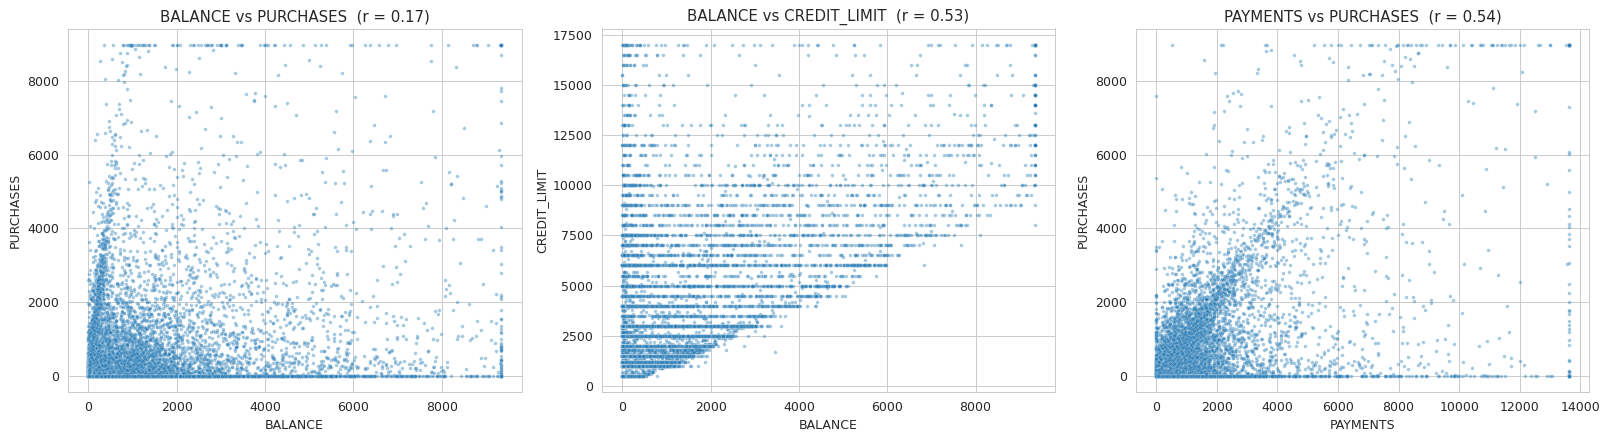

In [21]:
# Scatter: BALANCE vs PURCHASES (+ a few other numeric pairs)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x, y) in zip(axes, [("BALANCE","PURCHASES"), ("BALANCE","CREDIT_LIMIT"), ("PAYMENTS","PURCHASES")]):
    sns.scatterplot(data=df_clean, x=x, y=y, s=8, alpha=0.4, ax=ax)
    ax.set_title(f"{x} vs {y}  (r = {df_clean[x].corr(df_clean[y]):.2f})")
plt.tight_layout(); plt.show()

Visualize the relationship between categorical and numerical variables: Create box plots or violin plots to compare the distribution of a numerical variable across different categories of a categorical variable (e.g., compare the distribution of PURCHASES for different CUST_ID categories).

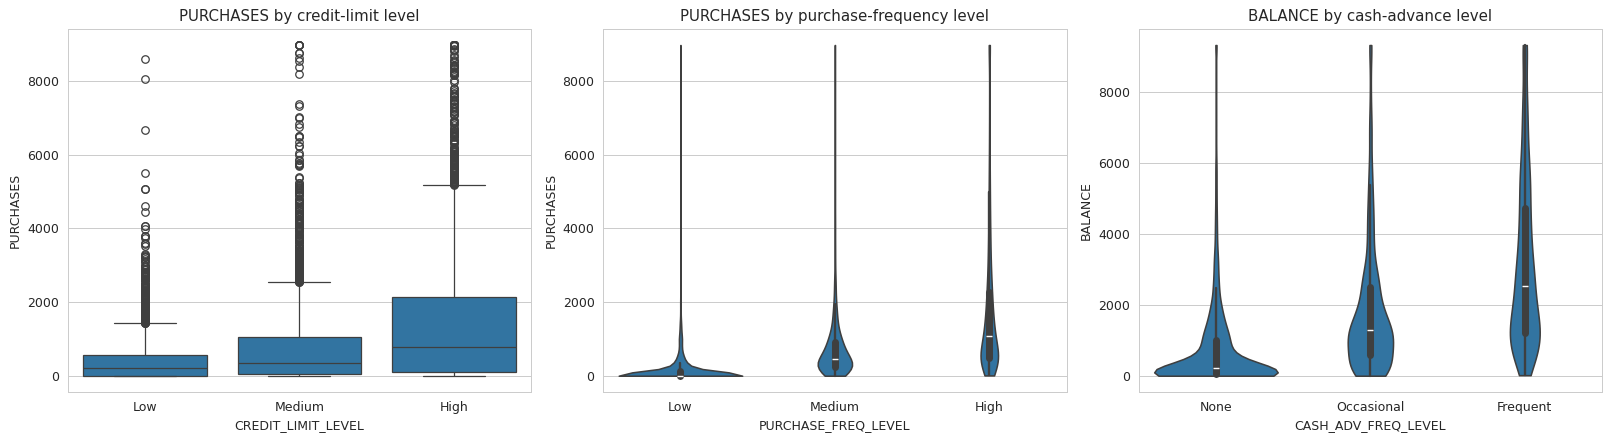

(CUST_ID cannot be used as a category here: each ID has exactly one row.)


In [22]:
# Categorical vs numerical: box and violin plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
order = ["Low", "Medium", "High"]
sns.boxplot(data=df_clean, x="CREDIT_LIMIT_LEVEL", y="PURCHASES", order=order, ax=axes[0]); axes[0].set_title("PURCHASES by credit-limit level")
sns.violinplot(data=df_clean, x="PURCHASE_FREQ_LEVEL", y="PURCHASES", order=order, ax=axes[1], cut=0); axes[1].set_title("PURCHASES by purchase-frequency level")
sns.violinplot(data=df_clean, x="CASH_ADV_FREQ_LEVEL", y="BALANCE", order=["None","Occasional","Frequent"], ax=axes[2], cut=0); axes[2].set_title("BALANCE by cash-advance level")
plt.tight_layout(); plt.show()
print("(CUST_ID cannot be used as a category here: each ID has exactly one row.)")

Visualize the relationship between multiple variables: Create pair plots or correlation matrices to explore the relationships between multiple variables simultaneously.

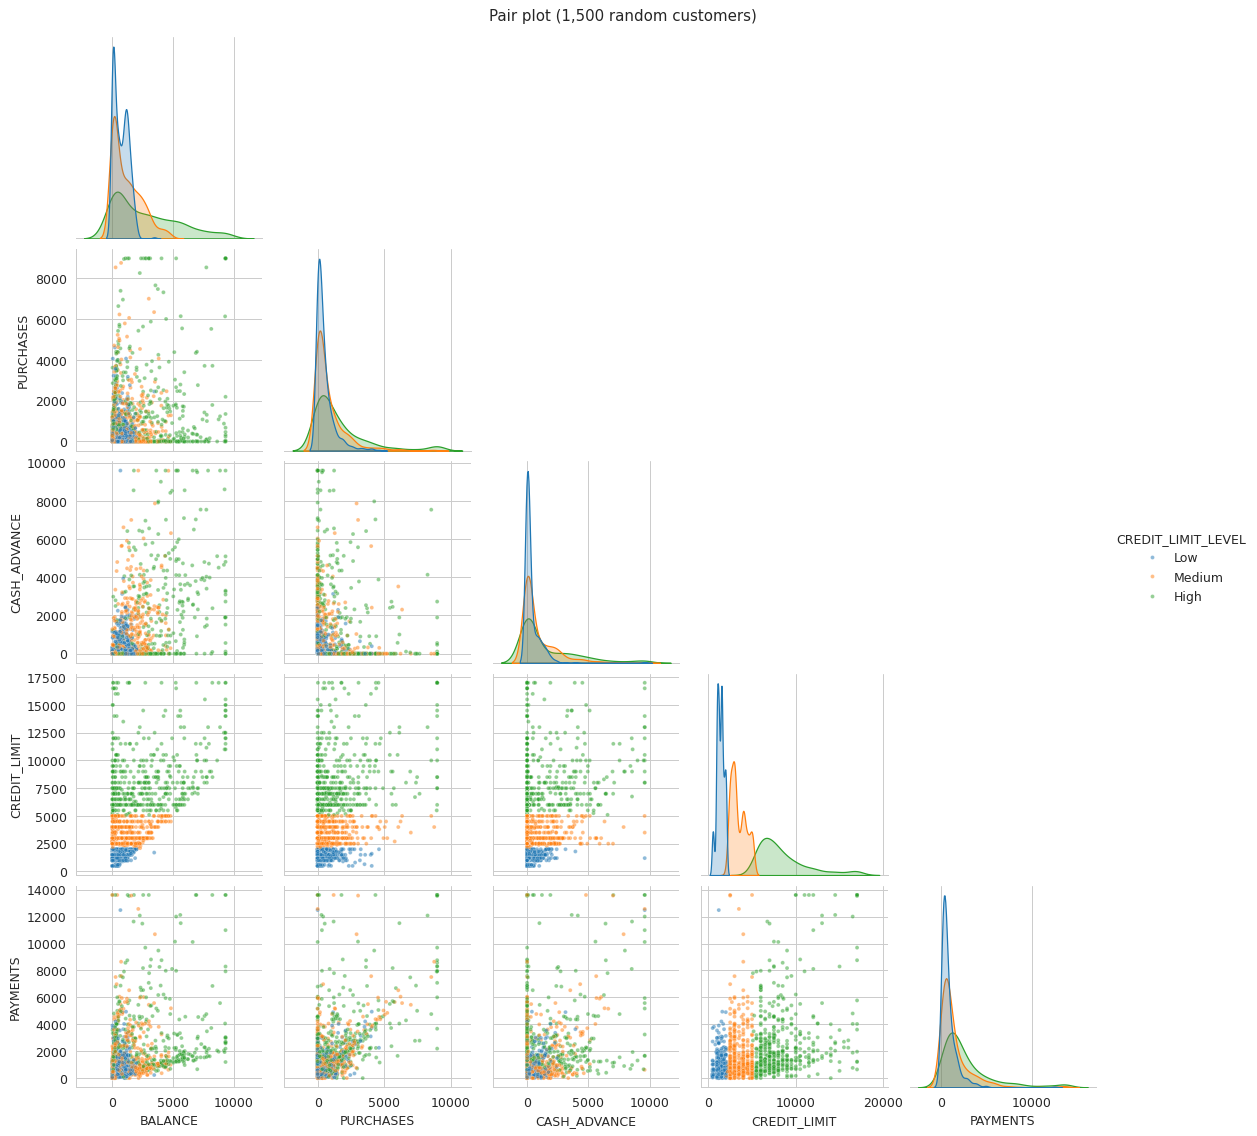

In [23]:
# Pair plot of the main variables, coloured by credit-limit level
pp_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]
sample = df_clean.sample(1500, random_state=RANDOM_STATE)
g = sns.pairplot(sample, vars=pp_cols, hue="CREDIT_LIMIT_LEVEL", hue_order=["Low","Medium","High"],
                 plot_kws={"s": 10, "alpha": 0.5}, corner=True)
g.fig.suptitle("Pair plot (1,500 random customers)", y=1.01); plt.show()

Visualize interactions between variables: Create interaction plots to examine how the relationship between two variables changes depending on the value of a third variable.

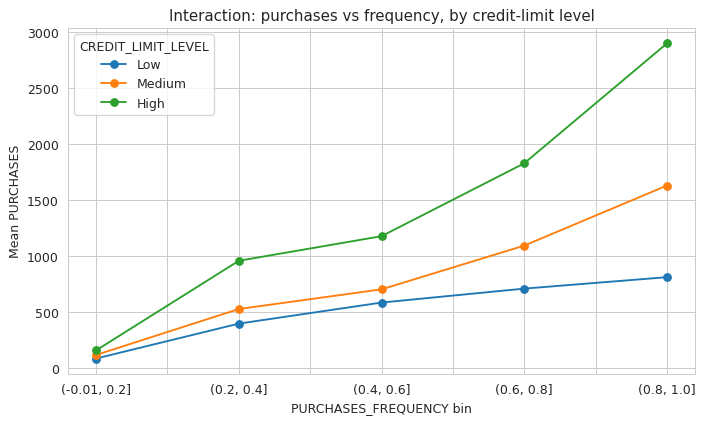

CREDIT_LIMIT_LEVEL    Low  Medium    High
PF_BIN                                   
(-0.01, 0.2]         86.0   118.0   159.0
(0.2, 0.4]          398.0   528.0   958.0
(0.4, 0.6]          585.0   703.0  1177.0
(0.6, 0.8]          710.0  1093.0  1827.0
(0.8, 1.0]          812.0  1629.0  2896.0

Mean purchases in the highest vs lowest frequency bin (x-fold):
CREDIT_LIMIT_LEVEL
Low        9.4
Medium    13.8
High      18.2
dtype: float64
Lines that are not parallel (different slopes) indicate an interaction between frequency and credit-limit level.


In [24]:
# Interaction plot: how does PURCHASES vs PURCHASES_FREQUENCY change with credit-limit level?
df_clean["PF_BIN"] = pd.cut(df_clean["PURCHASES_FREQUENCY"], bins=[-0.01, 0.2, 0.4, 0.6, 0.8, 1.0])
inter = df_clean.groupby(["PF_BIN", "CREDIT_LIMIT_LEVEL"], observed=True)["PURCHASES"].mean().unstack()
inter.index = inter.index.astype(str)
inter[["Low", "Medium", "High"]].plot(marker="o", figsize=(9, 5))
plt.ylabel("Mean PURCHASES"); plt.xlabel("PURCHASES_FREQUENCY bin")
plt.title("Interaction: purchases vs frequency, by credit-limit level"); plt.show()
print(inter.round(0))
rise = inter.iloc[-1] / inter.iloc[0]
print("\nMean purchases in the highest vs lowest frequency bin (x-fold):")
print(rise.round(1))
print("Lines that are not parallel (different slopes) indicate an interaction between frequency and credit-limit level.")
df_clean.drop(columns="PF_BIN", inplace=True)

Visualize trends over time: Create line charts to plot numerical variables against time (if applicable), such as the evolution of BALANCE or PURCHASES over the last 6 months.

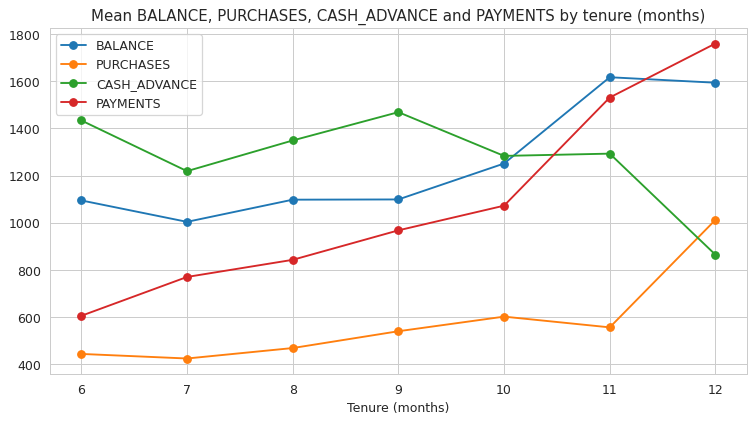

TENURE
6      204
7      190
8      196
9      175
10     236
11     365
12    7584
Name: count, dtype: int64


In [25]:
# Trends over time
# There is no calendar column in this snapshot dataset; the only time dimension is TENURE.
trend = df_clean.groupby("TENURE")[["BALANCE", "PURCHASES", "CASH_ADVANCE", "PAYMENTS"]].mean()
trend.plot(marker="o", figsize=(10, 5)); plt.title("Mean BALANCE, PURCHASES, CASH_ADVANCE and PAYMENTS by tenure (months)")
plt.xlabel("Tenure (months)"); plt.show()
print(df_clean["TENURE"].value_counts().sort_index())

Visualize seasonal patterns: Create seasonal decomposition plots to identify seasonal trends, cyclical patterns, and residuals in time-based data.

In [26]:
# Seasonal decomposition
# Seasonal decomposition needs an ordered time series (e.g. monthly totals). CreditCards.csv holds one
# row per customer with 6-month aggregates, so there are NO dates/periods to decompose.
# Decomposing the rows in file order would only produce meaningless "seasonality", so this step is
# deliberately not applicable to this dataset. (With a transaction-level table, we would use
# statsmodels.tsa.seasonal.seasonal_decompose(monthly_series, model="additive", period=12).)
print("Not applicable: the dataset has no time series.")

Not applicable: the dataset has no time series.


Visualize the distribution of credit limits: Create a histogram or box plot to understand the distribution of credit limits among customers. Are there any significant differences in credit limits between different customer segments?

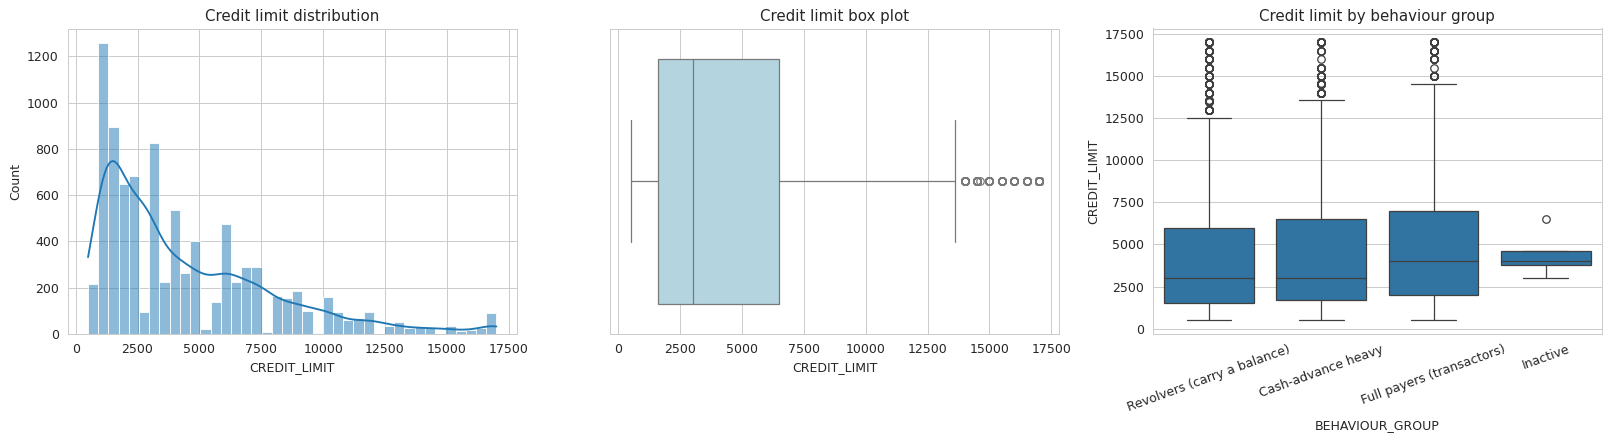

                               mean  median
BEHAVIOUR_GROUP                            
Cash-advance heavy           4499.0  3000.0
Full payers (transactors)    5104.0  4000.0
Inactive                     4375.0  4000.0
Revolvers (carry a balance)  4300.0  3000.0


In [27]:
# Credit limit distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_clean["CREDIT_LIMIT"], bins=40, kde=True, ax=axes[0]); axes[0].set_title("Credit limit distribution")
sns.boxplot(x=df_clean["CREDIT_LIMIT"], ax=axes[1], color="lightblue"); axes[1].set_title("Credit limit box plot")
sns.boxplot(data=df_clean, x="BEHAVIOUR_GROUP", y="CREDIT_LIMIT", ax=axes[2]); axes[2].set_title("Credit limit by behaviour group")
axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
print(df_clean.groupby("BEHAVIOUR_GROUP")["CREDIT_LIMIT"].agg(["mean", "median"]).round(0))

Visualize the relationship between payment patterns and delinquency: Create a scatter plot to examine the relationship between the percentage of full payments made (PRCFULLPAYMENT) and the number of times the minimum payment was not made (MINIMUM_PAYMENTS). Are there any patterns indicating which customers are more likely to be delinquent?

Customers paying less than the minimum due: 2640 (29.5%)


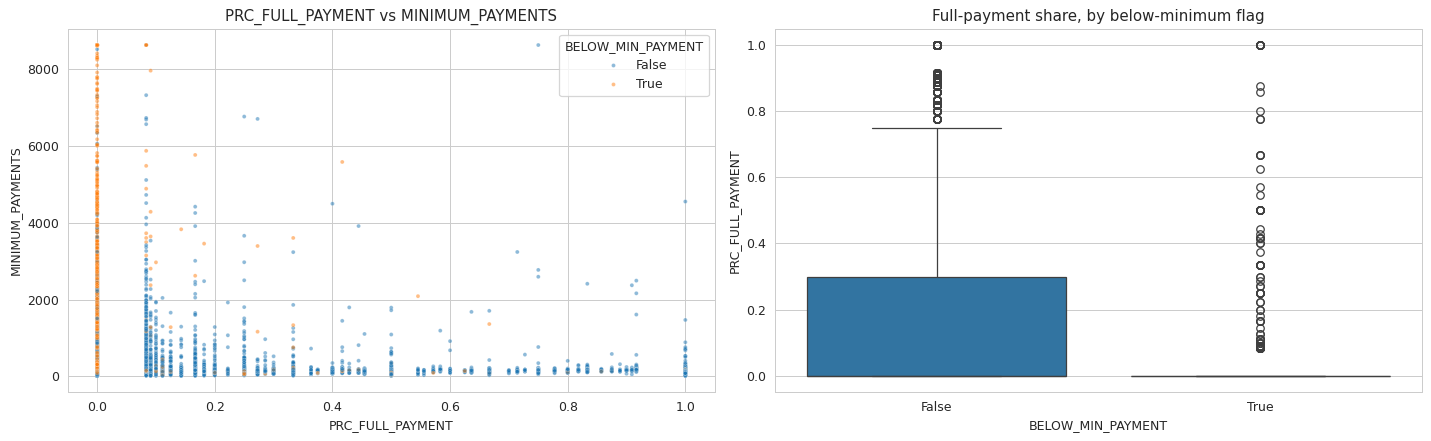

                   PRC_FULL_PAYMENT  BALANCE  CREDIT_LIMIT
BELOW_MIN_PAYMENT                                         
False                          0.21  1227.26       4702.69
True                           0.01  2291.04       3928.26


In [28]:
# Payment patterns vs delinquency risk
# MINIMUM_PAYMENTS is an amount (not a count of missed payments). A customer whose total PAYMENTS are
# below the MINIMUM_PAYMENTS due is a possible delinquency risk, so we build that indicator.
df_clean["PAYMENT_TO_MIN_RATIO"] = df_clean["PAYMENTS"] / df_clean["MINIMUM_PAYMENTS"].replace(0, np.nan)
df_clean["BELOW_MIN_PAYMENT"] = df_clean["PAYMENT_TO_MIN_RATIO"] < 1
print("Customers paying less than the minimum due: %d (%.1f%%)" %
      (df_clean["BELOW_MIN_PAYMENT"].sum(), 100 * df_clean["BELOW_MIN_PAYMENT"].mean()))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=df_clean, x="PRC_FULL_PAYMENT", y="MINIMUM_PAYMENTS", hue="BELOW_MIN_PAYMENT", s=10, alpha=0.5, ax=axes[0])
axes[0].set_title("PRC_FULL_PAYMENT vs MINIMUM_PAYMENTS")
sns.boxplot(data=df_clean, x="BELOW_MIN_PAYMENT", y="PRC_FULL_PAYMENT", ax=axes[1]); axes[1].set_title("Full-payment share, by below-minimum flag")
plt.tight_layout(); plt.show()
print(df_clean.groupby("BELOW_MIN_PAYMENT")[["PRC_FULL_PAYMENT", "BALANCE", "CREDIT_LIMIT"]].mean().round(2))

Visualize the distribution of tenure: Create a histogram or bar chart to understand the distribution of credit card tenure among customers. Are there any significant differences in tenure between different customer segments?

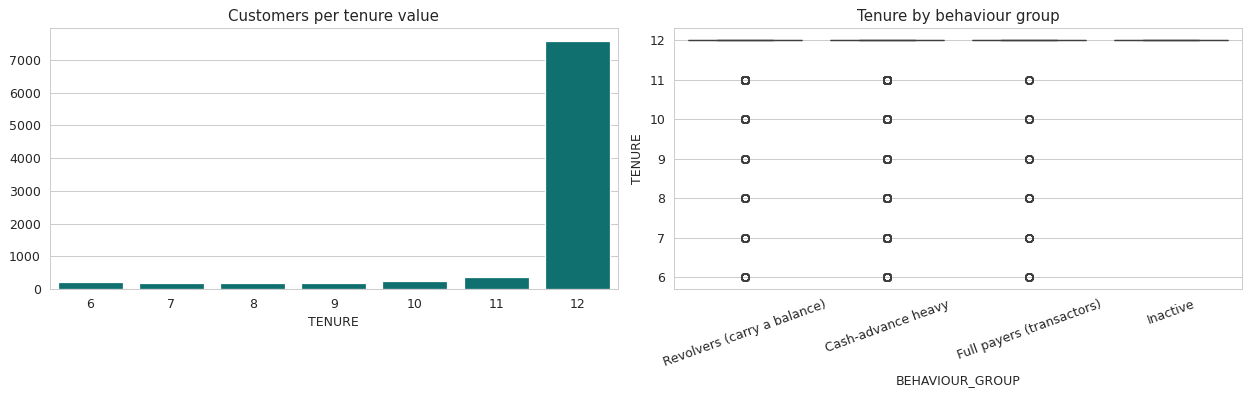

Share with 12 months tenure: 84.7%
BEHAVIOUR_GROUP
Cash-advance heavy             11.33
Full payers (transactors)      11.53
Inactive                       12.00
Revolvers (carry a balance)    11.67
Name: TENURE, dtype: float64


In [29]:
# Tenure distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
tc = df_clean["TENURE"].value_counts().sort_index()
sns.barplot(x=tc.index, y=tc.values, ax=axes[0], color="teal"); axes[0].set_title("Customers per tenure value")
sns.boxplot(data=df_clean, x="BEHAVIOUR_GROUP", y="TENURE", ax=axes[1]); axes[1].tick_params(axis="x", rotation=20); axes[1].set_title("Tenure by behaviour group")
plt.tight_layout(); plt.show()
print("Share with 12 months tenure: %.1f%%" % (100 * (df_clean.TENURE == 12).mean()))
print(df_clean.groupby("BEHAVIOUR_GROUP")["TENURE"].mean().round(2))

Visualize the relationship between purchase frequency and purchase amount: Create a scatter plot to examine the relationship between the frequency of purchases (PURCHASES_FREQUENCY) and the total purchase amount (PURCHASES). Are there any patterns indicating which customers are more likely to make larger purchases?

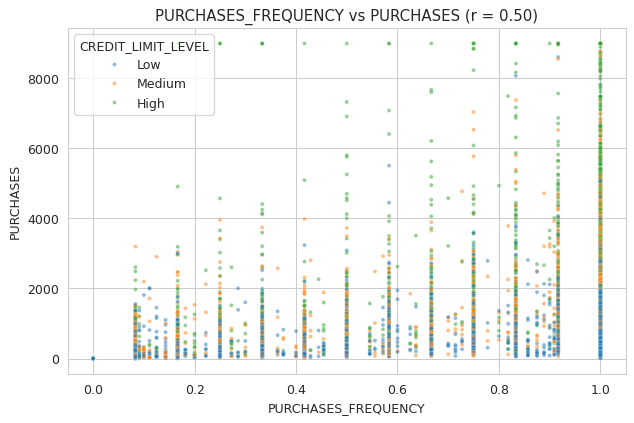

                       mean     50%     max
PURCHASE_FREQ_LEVEL                        
Low                   166.0     0.0  8977.0
Medium                763.0   463.0  8977.0
High                 1763.0  1073.0  8977.0


In [30]:
# Purchase frequency vs purchase amount
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="PURCHASES_FREQUENCY", y="PURCHASES", hue="CREDIT_LIMIT_LEVEL",
                hue_order=["Low","Medium","High"], s=10, alpha=0.5)
plt.title("PURCHASES_FREQUENCY vs PURCHASES (r = %.2f)" % df_clean["PURCHASES_FREQUENCY"].corr(df_clean["PURCHASES"]))
plt.show()
print(df_clean.groupby("PURCHASE_FREQ_LEVEL", observed=True)["PURCHASES"].describe()[["mean","50%","max"]].round(0))

Visualize the relationship between cash advance usage and purchase behavior: Create a scatter plot to examine the relationship between the amount of cash advances (CASH_ADVANCE) and the total purchase amount (PURCHASES). Are there any patterns indicating which customers are more likely to use cash advances and how this affects their purchase behavior?

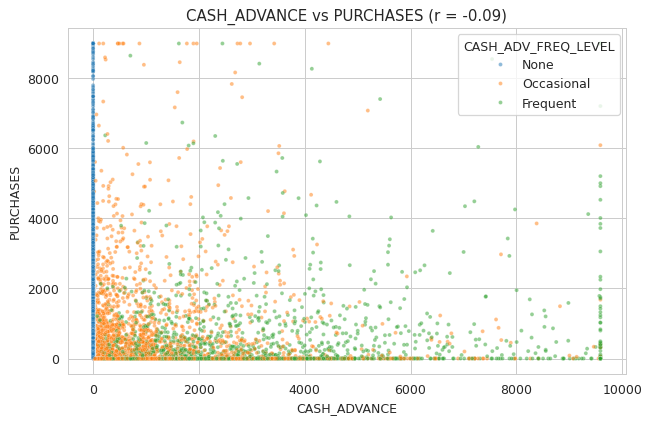

                     PURCHASES  BALANCE  PRC_FULL_PAYMENT
CASH_ADV_FREQ_LEVEL                                      
None                   1245.61   782.03              0.25
Occasional              610.94  1881.71              0.06
Frequent                594.33  3191.32              0.04


In [31]:
# Cash advance vs purchases
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="CASH_ADVANCE", y="PURCHASES", hue="CASH_ADV_FREQ_LEVEL", s=10, alpha=0.5)
plt.title("CASH_ADVANCE vs PURCHASES (r = %.2f)" % df_clean["CASH_ADVANCE"].corr(df_clean["PURCHASES"]))
plt.show()
print(df_clean.groupby("CASH_ADV_FREQ_LEVEL", observed=True)[["PURCHASES","BALANCE","PRC_FULL_PAYMENT"]].mean().round(2))

## Data Preprocessing

Scale numerical variables to a common range (e.g., 0-1 or -1 to 1) using techniques like min-max scaling or standardization to improve model performance and prevent numerical instability.

In [32]:
# Scale the numerical variables
# df_clean now holds the cleaned numeric features. (CUST_ID is just an ID and is excluded.)
base_features = [c for c in num_cols]                      # the 17 original numeric columns
X_base = df_clean[base_features]

std_scaler = StandardScaler()
X_standard = pd.DataFrame(std_scaler.fit_transform(X_base), columns=base_features)    # mean 0, std 1
mm_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(mm_scaler.fit_transform(X_base), columns=base_features)       # range 0-1

print("Standardisation -> mean ~ 0, std ~ 1")
print(X_standard.agg(["mean", "std"]).round(3).T.head(6))
print("\nMin-max scaling -> min 0, max 1")
print(X_minmax.agg(["min", "max"]).round(3).T.head(6))
print("\nWe use standardisation for the clustering pipeline (distance-based algorithms + PCA need it).")

Standardisation -> mean ~ 0, std ~ 1
                        mean  std
BALANCE                 -0.0  1.0
BALANCE_FREQUENCY        0.0  1.0
PURCHASES               -0.0  1.0
ONEOFF_PURCHASES        -0.0  1.0
INSTALLMENTS_PURCHASES   0.0  1.0
CASH_ADVANCE            -0.0  1.0

Min-max scaling -> min 0, max 1
                        min  max
BALANCE                 0.0  1.0
BALANCE_FREQUENCY       0.0  1.0
PURCHASES               0.0  1.0
ONEOFF_PURCHASES        0.0  1.0
INSTALLMENTS_PURCHASES  0.0  1.0
CASH_ADVANCE            0.0  1.0

We use standardisation for the clustering pipeline (distance-based algorithms + PCA need it).


Convert categorical variables to numerical representations using techniques like one-hot encoding or label encoding, depending on the nature of the variables.

In [33]:
# Encode the categorical variables
# CUST_ID is an identifier -> dropped (one-hot would create 8,950 useless columns).
# The derived categories are encoded: ordered ones with label encoding, nominal ones with one-hot.
ordinal_map = {"Low": 0, "Medium": 1, "High": 2}
encoded = pd.DataFrame({
    "CREDIT_LIMIT_LEVEL_ENC": df_clean["CREDIT_LIMIT_LEVEL"].map(ordinal_map),
    "PURCHASE_FREQ_LEVEL_ENC": df_clean["PURCHASE_FREQ_LEVEL"].map(ordinal_map),
})
onehot = pd.get_dummies(df_clean[["BEHAVIOUR_GROUP", "CASH_ADV_FREQ_LEVEL"]].astype(str), drop_first=False).astype(int)
cat_encoded = pd.concat([encoded, onehot], axis=1)
print(cat_encoded.head())
print("\nThese encoded columns are only used for profiling: they are built from numeric features that are "
      "already in the model, so adding them to the clustering would double-count the same information.")

  CREDIT_LIMIT_LEVEL_ENC PURCHASE_FREQ_LEVEL_ENC  BEHAVIOUR_GROUP_Cash-advance heavy  BEHAVIOUR_GROUP_Full payers (transactors)  BEHAVIOUR_GROUP_Inactive  BEHAVIOUR_GROUP_Revolvers (carry a balance)  CASH_ADV_FREQ_LEVEL_Frequent  \
0                      0                       0                                   0                                          0                         0                                            1                             0   
1                      2                       0                                   1                                          0                         0                                            0                             0   
2                      2                       2                                   0                                          0                         0                                            1                             0   
3                      2                       0                        

## Feature Engineering

Combine existing features to capture interactions between them (e.g., multiply BALANCE and PURCHASES_FREQUENCY to create a new feature representing the total spending per unit time).

In [34]:
# Feature engineering - interactions
def safe_div(a, b):
    return (a / b.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0)

df_fe = df_clean[base_features].copy()
df_fe["BALANCE_X_PURCH_FREQ"] = df_fe["BALANCE"] * df_fe["PURCHASES_FREQUENCY"]
df_fe["PURCHASES_X_FREQ"] = df_fe["PURCHASES"] * df_fe["PURCHASES_FREQUENCY"]
df_fe["CASH_ADV_X_FREQ"] = df_fe["CASH_ADVANCE"] * df_fe["CASH_ADVANCE_FREQUENCY"]
df_fe[["BALANCE_X_PURCH_FREQ", "PURCHASES_X_FREQ", "CASH_ADV_X_FREQ"]].describe().round(2)

,BALANCE_X_PURCH_FREQ,PURCHASES_X_FREQ,CASH_ADV_X_FREQ
count,8950.00,8950.00,8950.00
mean,686.84,767.71,362.72
std,1384.04,1443.12,948.06
min,0.00,0.00,0.00
25%,0.60,3.90,0.00
50%,101.62,185.57,0.00
75%,691.04,808.38,220.08
max,9338.80,8977.29,7990.13


Derive new features by calculating ratios or percentages between existing features (e.g., calculate the percentage of credit limit used by dividing BALANCE by CREDIT_LIMIT).

In [35]:
# Ratios / percentages
df_fe["CREDIT_UTILIZATION"] = safe_div(df_fe["BALANCE"], df_fe["CREDIT_LIMIT"])          # share of limit used
df_fe["PAYMENT_TO_BALANCE"] = safe_div(df_fe["PAYMENTS"], df_fe["BALANCE"])
df_fe["PAYMENT_TO_MIN_RATIO"] = safe_div(df_fe["PAYMENTS"], df_fe["MINIMUM_PAYMENTS"])
df_fe["ONEOFF_SHARE"] = safe_div(df_fe["ONEOFF_PURCHASES"], df_fe["PURCHASES"])
df_fe["INSTALLMENT_SHARE"] = safe_div(df_fe["INSTALLMENTS_PURCHASES"], df_fe["PURCHASES"])
df_fe["AVG_PURCHASE_PER_TRX"] = safe_div(df_fe["PURCHASES"], df_fe["PURCHASES_TRX"])
df_fe["AVG_CASH_ADV_PER_TRX"] = safe_div(df_fe["CASH_ADVANCE"], df_fe["CASH_ADVANCE_TRX"])
ratio_cols = ["CREDIT_UTILIZATION","PAYMENT_TO_BALANCE","PAYMENT_TO_MIN_RATIO","ONEOFF_SHARE","INSTALLMENT_SHARE","AVG_PURCHASE_PER_TRX","AVG_CASH_ADV_PER_TRX"]
df_fe[ratio_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
CREDIT_UTILIZATION,8950.0,0.39,0.35,0.0,0.04,0.30,0.71,2.03
PAYMENT_TO_BALANCE,8950.0,108.77,2843.77,0.0,0.33,1.41,7.61,209041.35
PAYMENT_TO_MIN_RATIO,8950.0,5.52,14.92,0.0,0.91,2.02,6.01,679.06
ONEOFF_SHARE,8950.0,0.38,0.42,0.0,0.00,0.11,0.86,1.80
INSTALLMENT_SHARE,8950.0,0.39,0.43,0.0,0.00,0.19,1.00,2.96
AVG_PURCHASE_PER_TRX,8950.0,72.71,147.07,0.0,12.00,41.61,78.21,2992.43
AVG_CASH_ADV_PER_TRX,8950.0,206.44,512.17,0.0,0.00,0.00,248.07,9588.16


Extract time-based features from dates or timestamps (e.g., create features for day of week, month, or year).

In [36]:
# Time-based features
# There are no dates/timestamps in this dataset, so day-of-week / month / year cannot be extracted.
# The closest "time" information is TENURE (months) and the 6-month observation window, so we derive:
df_fe["TENURE_YEARS"] = df_fe["TENURE"] / 12
df_fe["PURCHASES_PER_TENURE_MONTH"] = df_fe["PURCHASES"] / df_fe["TENURE"]
df_fe["AVG_MONTHLY_PURCHASES_6M"] = df_fe["PURCHASES"] / 6
df_fe[["TENURE_YEARS", "PURCHASES_PER_TENURE_MONTH", "AVG_MONTHLY_PURCHASES_6M"]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
TENURE_YEARS,8950.0,0.96,0.11,0.5,1.00,1.00,1.00,1.00
PURCHASES_PER_TENURE_MONTH,8950.0,80.56,129.76,0.0,3.40,31.94,97.23,1422.26
AVG_MONTHLY_PURCHASES_6M,8950.0,156.04,254.20,0.0,6.61,60.21,185.02,1496.22


Create new features by grouping data and calculating summary statistics within each group (e.g., calculate the average purchase amount for each customer segment).

In [37]:
# Group-based summary statistics added as features
df_fe["CREDIT_LIMIT_LEVEL"] = df_clean["CREDIT_LIMIT_LEVEL"].values
df_fe["GRP_MEAN_PURCHASES"] = df_fe.groupby("CREDIT_LIMIT_LEVEL", observed=True)["PURCHASES"].transform("mean")
df_fe["GRP_MEAN_BALANCE"] = df_fe.groupby("CREDIT_LIMIT_LEVEL", observed=True)["BALANCE"].transform("mean")
df_fe["PURCHASES_VS_GROUP"] = safe_div(df_fe["PURCHASES"], df_fe["GRP_MEAN_PURCHASES"])   # >1 = spends more than peers
print(df_fe[["CREDIT_LIMIT_LEVEL", "GRP_MEAN_PURCHASES", "GRP_MEAN_BALANCE", "PURCHASES_VS_GROUP"]].drop_duplicates("CREDIT_LIMIT_LEVEL").sort_values("GRP_MEAN_BALANCE"))

  CREDIT_LIMIT_LEVEL  GRP_MEAN_PURCHASES  GRP_MEAN_BALANCE  PURCHASES_VS_GROUP
0                Low          441.631967        655.116741            0.216017
7             Medium          794.972760       1204.169941            0.548698
1               High         1595.778295       2811.042309            0.000000


Leverage domain knowledge to create new features that are relevant to the problem at hand (e.g., create a feature indicating whether a customer has made a purchase in the last 30 days).

In [38]:
# Domain-knowledge features
# (no purchase dates exist, so "purchased in the last 30 days" is replaced by "purchased at all in the period")
df_fe["HAS_PURCHASED"] = (df_fe["PURCHASES_TRX"] > 0).astype(int)
df_fe["USES_CASH_ADVANCE"] = (df_fe["CASH_ADVANCE_TRX"] > 0).astype(int)
df_fe["IS_FULL_PAYER"] = (df_fe["PRC_FULL_PAYMENT"] >= 0.5).astype(int)
df_fe["BELOW_MIN_PAYMENT_FLAG"] = (df_fe["PAYMENT_TO_MIN_RATIO"] < 1).astype(int)
df_fe["HIGH_UTILIZATION"] = (df_fe["CREDIT_UTILIZATION"] > 0.7).astype(int)
df_fe[["HAS_PURCHASED","USES_CASH_ADVANCE","IS_FULL_PAYER","BELOW_MIN_PAYMENT_FLAG","HIGH_UTILIZATION"]].mean().round(3)

HAS_PURCHASED             0.772
USES_CASH_ADVANCE         0.483
IS_FULL_PAYER             0.143
BELOW_MIN_PAYMENT_FLAG    0.295
HIGH_UTILIZATION          0.254
dtype: float64

Create polynomial features by raising existing numerical features to powers (e.g., create features for BALANCE^2 and PURCHASES^2).

In [39]:
# Polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr = poly.fit_transform(df_fe[["BALANCE", "PURCHASES"]])
poly_df = pd.DataFrame(poly_arr, columns=poly.get_feature_names_out(["BALANCE", "PURCHASES"]), index=df_fe.index)
df_fe["BALANCE_SQ"] = poly_df["BALANCE^2"]
df_fe["PURCHASES_SQ"] = poly_df["PURCHASES^2"]
print(poly_df.columns.tolist())
df_fe[["BALANCE_SQ", "PURCHASES_SQ"]].describe().round(0).T

['BALANCE', 'PURCHASES', 'BALANCE^2', 'BALANCE PURCHASES', 'PURCHASES^2']

,count,mean,std,min,25%,50%,75%,max
BALANCE_SQ,8950.0,6241898.0,14563063.0,0.0,16456.0,762802.0,4219491.0,87213275.0
PURCHASES_SQ,8950.0,3202455.0,10744254.0,0.0,1571.0,130523.0,1232389.0,80591736.0


Calculate the difference between time-based features (e.g., calculate the difference between the last purchase date and the last payment date).

In [40]:
# Differences between time-related / paired features
# (no dates exist, so we take differences between paired activity measures instead)
df_fe["FREQ_PURCH_MINUS_CASH"] = df_fe["PURCHASES_FREQUENCY"] - df_fe["CASH_ADVANCE_FREQUENCY"]
df_fe["FREQ_ONEOFF_MINUS_INSTALL"] = df_fe["ONEOFF_PURCHASES_FREQUENCY"] - df_fe["PURCHASES_INSTALLMENTS_FREQUENCY"]
df_fe["PAYMENTS_MINUS_PURCHASES"] = df_fe["PAYMENTS"] - df_fe["PURCHASES"]
df_fe[["FREQ_PURCH_MINUS_CASH", "FREQ_ONEOFF_MINUS_INSTALL", "PAYMENTS_MINUS_PURCHASES"]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
FREQ_PURCH_MINUS_CASH,8950.0,0.36,0.50,-0.83,-0.08,0.33,0.83,1.00
FREQ_ONEOFF_MINUS_INSTALL,8950.0,-0.16,0.46,-1.00,-0.50,0.00,0.08,1.00
PAYMENTS_MINUS_PURCHASES,8950.0,713.19,1926.88,-8468.49,-47.74,232.96,905.67,13608.72


Group data by specific criteria and calculate custom aggregations (e.g., calculate the median purchase amount for each customer segment).

In [41]:
# Group by criteria and compute custom aggregations
agg = df_fe.groupby("CREDIT_LIMIT_LEVEL", observed=True).agg(
    n_customers=("BALANCE", "size"),
    median_purchases=("PURCHASES", "median"),
    median_balance=("BALANCE", "median"),
    p90_cash_advance=("CASH_ADVANCE", lambda s: s.quantile(0.9)),
    mean_utilization=("CREDIT_UTILIZATION", "mean"),
    pct_full_payers=("IS_FULL_PAYER", "mean"),
)
print(agg.round(2))
agg2 = df_fe.assign(BEHAVIOUR_GROUP=df_clean["BEHAVIOUR_GROUP"].values).groupby("BEHAVIOUR_GROUP").agg(
    n=("BALANCE", "size"), median_purchases=("PURCHASES", "median"), median_cash_adv=("CASH_ADVANCE", "median"))
print(); print(agg2.round(1))

                    n_customers  median_purchases  median_balance  p90_cash_advance  mean_utilization  pct_full_payers
CREDIT_LIMIT_LEVEL                                                                                                    
Low                        2990            222.89          541.19           1172.28              0.48             0.12
Medium                     3062            353.07          816.64           2706.43              0.35             0.15
High                       2898            766.77         2073.03           5453.59              0.32             0.16



                                n  median_purchases  median_cash_adv
BEHAVIOUR_GROUP                                                     
Cash-advance heavy           3491               0.0           1483.9
Full payers (transactors)    1074             919.8              0.0
Inactive                        4               0.0              0.0
Revolvers (carry a balance)  4381             650.0              0.0


Use feature selection techniques (e.g., correlation analysis, recursive feature elimination) to identify the most important features and remove redundant or irrelevant ones.

In [42]:
# Feature selection
# Candidate numeric features = the originals + engineered continuous/ratio features
# (in this order, so originals are preferred when two features are redundant).
engineered = ["BALANCE_X_PURCH_FREQ","PURCHASES_X_FREQ","CASH_ADV_X_FREQ","CREDIT_UTILIZATION","PAYMENT_TO_BALANCE",
              "PAYMENT_TO_MIN_RATIO","ONEOFF_SHARE","INSTALLMENT_SHARE","AVG_PURCHASE_PER_TRX","AVG_CASH_ADV_PER_TRX",
              "TENURE_YEARS","PURCHASES_PER_TENURE_MONTH","PURCHASES_VS_GROUP","BALANCE_SQ","PURCHASES_SQ",
              "FREQ_PURCH_MINUS_CASH","FREQ_ONEOFF_MINUS_INSTALL","PAYMENTS_MINUS_PURCHASES"]
candidates = base_features + engineered
print("Candidate features:", len(candidates))

# 1) drop near-constant features
vt = VarianceThreshold(threshold=1e-6).fit(StandardScaler().fit_transform(df_fe[candidates]))
candidates = [c for c, keep in zip(candidates, vt.get_support()) if keep]

# 2) drop one feature of each highly correlated pair (|r| > 0.85)
corr_c = df_fe[candidates].corr().abs()
selected, dropped = [], {}
for c in candidates:
    clash = [s for s in selected if corr_c.loc[c, s] > 0.85]
    if clash: dropped[c] = clash[0]
    else:     selected.append(c)
print("\nDropped (redundant) -> kept feature it duplicates:")
for k, v in dropped.items(): print(f"  {k:28s} ~ {v}")
print(f"\nSelected {len(selected)} features:\n", selected)

Candidate features: 35

Dropped (redundant) -> kept feature it duplicates:
  ONEOFF_PURCHASES             ~ PURCHASES
  PURCHASES_INSTALLMENTS_FREQUENCY ~ PURCHASES_FREQUENCY
  CASH_ADVANCE_TRX             ~ CASH_ADVANCE_FREQUENCY
  PURCHASES_X_FREQ             ~ PURCHASES
  CASH_ADV_X_FREQ              ~ CASH_ADVANCE
  TENURE_YEARS                 ~ TENURE
  PURCHASES_PER_TENURE_MONTH   ~ PURCHASES
  BALANCE_SQ                   ~ BALANCE
  PURCHASES_SQ                 ~ PURCHASES
  FREQ_PURCH_MINUS_CASH        ~ PURCHASES_FREQUENCY

Selected 25 features:
 ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'BALANCE_X_PURCH_FREQ', 'CREDIT_UTILIZATION', 'PAYMENT_TO_BALANCE', 'PAYMENT_TO_MIN_RATIO', 'ONEOFF_SHARE', 'INSTALLMENT_SHARE', 'AVG_PURCHASE_PER_TRX', 'AVG_CASH_ADV_PER_TRX

## PCA

Standardize the numerical features to ensure they have a mean of 0 and a standard deviation of 1, as PCA is sensitive to the scale of the variables.

In [43]:
# Standardise the selected features (mean 0, std 1)
# Most money/count columns are very right-skewed, which lets a few big values dominate the distances,
# so we apply log1p to strongly skewed non-negative features first, then standardise.
X_sel = df_fe[selected].copy()
skew = X_sel.skew()
log_cols = [c for c in selected if skew[c] > 1.5 and X_sel[c].min() >= 0]
X_sel[log_cols] = np.log1p(X_sel[log_cols])
print("log1p applied to:", log_cols)

X_std = StandardScaler().fit_transform(X_sel)
print("\nmean (should be ~0):", np.round(X_std.mean(axis=0)[:5], 3), "...")
print("std  (should be ~1):", np.round(X_std.std(axis=0)[:5], 3), "...")
print("Shape:", X_std.shape)

log1p applied to: ['BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'ONEOFF_PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PURCHASES_TRX', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'BALANCE_X_PURCH_FREQ', 'PAYMENT_TO_BALANCE', 'PAYMENT_TO_MIN_RATIO', 'AVG_PURCHASE_PER_TRX', 'AVG_CASH_ADV_PER_TRX', 'PURCHASES_VS_GROUP']

mean (should be ~0): [-0.  0. -0.  0.  0.] ...
std  (should be ~1): [1. 1. 1. 1. 1.] ...
Shape: (8950, 25)


Compute the covariance matrix of the standardized data to measure the relationships between the variables.

Covariance matrix shape: (25, 25)


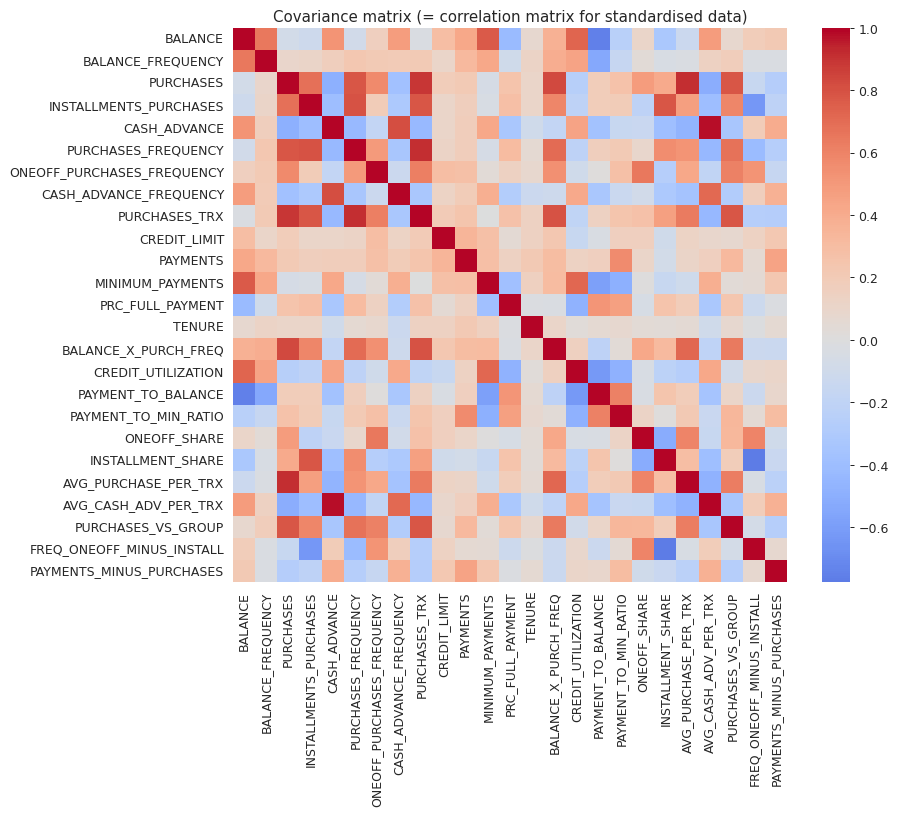

In [44]:
# Covariance matrix of the standardised data
cov_matrix = np.cov(X_std, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(cov_matrix, index=selected, columns=selected), cmap="coolwarm", center=0, square=True)
plt.title("Covariance matrix (= correlation matrix for standardised data)"); plt.show()

Decompose the covariance matrix into its eigenvectors and eigenvalues, which represent the principal components and their corresponding variances.

In [45]:
# Eigen-decomposition of the covariance matrix
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)          # eigh: symmetric matrix
order = np.argsort(eig_vals)[::-1]                        # largest variance first
eig_vals, eig_vecs = eig_vals[order], eig_vecs[:, order]

explained = eig_vals / eig_vals.sum()
eig_table = pd.DataFrame({"eigenvalue": eig_vals, "explained_var": explained,
                          "cumulative_var": np.cumsum(explained)}, index=[f"PC{i+1}" for i in range(len(eig_vals))])
print(eig_table.round(4))

      eigenvalue  explained_var  cumulative_var
PC1       7.6447         0.3058          0.3058
PC2       4.8635         0.1945          0.5003
PC3       3.0445         0.1218          0.6220
PC4       2.4468         0.0979          0.7199
PC5       1.2201         0.0488          0.7687
PC6       1.0236         0.0409          0.8096
PC7       0.8929         0.0357          0.8453
PC8       0.7408         0.0296          0.8750
PC9       0.5614         0.0225          0.8974
PC10      0.5514         0.0221          0.9195
PC11      0.4527         0.0181          0.9376
PC12      0.3325         0.0133          0.9509
PC13      0.2777         0.0111          0.9620
PC14      0.2559         0.0102          0.9722
PC15      0.1957         0.0078          0.9801
PC16      0.1564         0.0063          0.9863
PC17      0.0986         0.0039          0.9903
PC18      0.0643         0.0026          0.9928
PC19      0.0625         0.0025          0.9953
PC20      0.0462         0.0018         

Choose the principal components with the highest eigenvalues, as these components explain the most variance in the data. The number of components to keep can be determined based on the desired level of dimensionality reduction or by analyzing the scree plot (a plot of the eigenvalues in descending order).

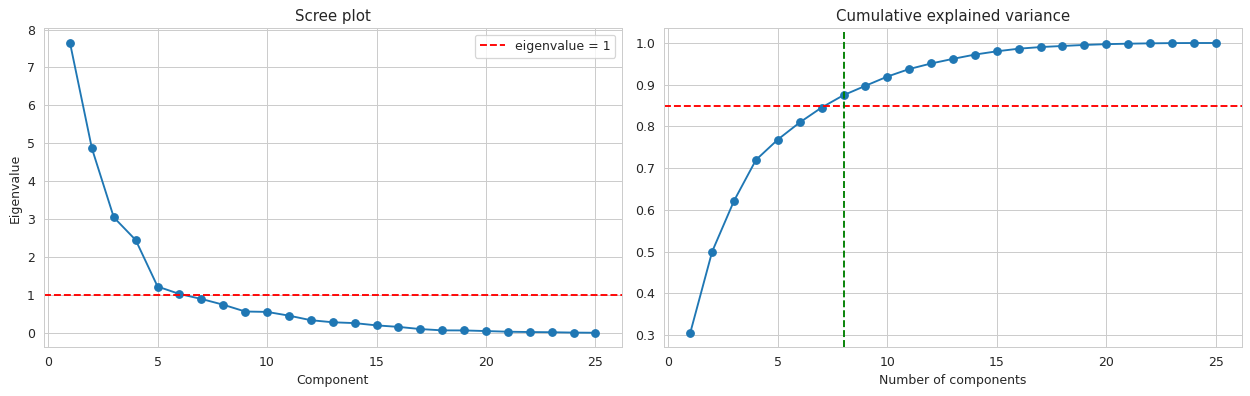

Components kept: 8  (explain 87.5% of the variance)


In [46]:
# Choose the number of components (scree plot + 85% cumulative variance rule)
cum = np.cumsum(explained)
n_components = int(np.argmax(cum >= 0.85) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(range(1, len(eig_vals) + 1), eig_vals, "o-"); axes[0].axhline(1, color="r", ls="--", label="eigenvalue = 1")
axes[0].set_title("Scree plot"); axes[0].set_xlabel("Component"); axes[0].set_ylabel("Eigenvalue"); axes[0].legend()
axes[1].plot(range(1, len(cum) + 1), cum, "o-"); axes[1].axhline(0.85, color="r", ls="--")
axes[1].axvline(n_components, color="g", ls="--"); axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Number of components"); plt.tight_layout(); plt.show()
print(f"Components kept: {n_components}  (explain {cum[n_components-1]*100:.1f}% of the variance)")

Project the original data onto the selected principal components to obtain the reduced-dimensional representation. The resulting features are the principal components, which are uncorrelated and capture the most important information in the data.

In [47]:
# Project the data on the selected components
W = eig_vecs[:, :n_components]
X_pca = X_std @ W                                   # (n_samples x n_components)
print("Reduced shape:", X_pca.shape)

# sanity check against scikit-learn
skl = PCA(n_components=n_components, random_state=RANDOM_STATE).fit(X_std)
print("Explained variance matches sklearn:", np.allclose(skl.explained_variance_, eig_vals[:n_components]))
print("Components are uncorrelated (max off-diagonal corr): %.2e" %
      np.abs(np.corrcoef(X_pca, rowvar=False) - np.eye(n_components)).max())

loadings = pd.DataFrame(W[:, :3], index=selected, columns=["PC1", "PC2", "PC3"])
print("\nTop loadings:")
for pc in loadings.columns:
    print(pc, loadings[pc].abs().sort_values(ascending=False).head(4).index.tolist())

Reduced shape: (8950, 8)
Explained variance matches sklearn: True
Components are uncorrelated (max off-diagonal corr): 6.59e-16

Top loadings:
PC1 ['PURCHASES', 'PURCHASES_TRX', 'PURCHASES_FREQUENCY', 'INSTALLMENTS_PURCHASES']
PC2 ['BALANCE', 'MINIMUM_PAYMENTS', 'BALANCE_X_PURCH_FREQ', 'BALANCE_FREQUENCY']
PC3 ['FREQ_ONEOFF_MINUS_INSTALL', 'ONEOFF_SHARE', 'INSTALLMENT_SHARE', 'ONEOFF_PURCHASES_FREQUENCY']


## DBSCAN

Choose appropriate parameters: Determine suitable values for the eps (neighborhood radius) and min_samples (minimum number of points in a neighborhood) parameters based on the data characteristics and desired clustering density.

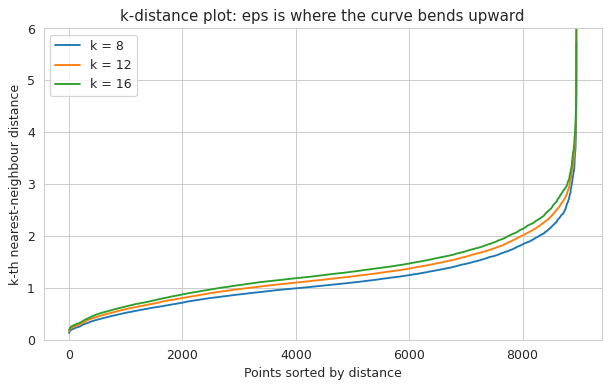

 min_samples  eps  n_clusters  noise_%  silhouette
          12  1.8           3      6.7       0.276
          10  1.8           5      5.7       0.179
           8  1.6           5      8.9       0.169
          10  1.6           5     10.0       0.158
           8  1.8           5      5.1       0.126

Chosen parameters -> eps = 1.8, min_samples = 12


In [48]:
# Choose eps and min_samples
# Rule of thumb: min_samples >= 2 x number of dimensions. We have 8 PCA dimensions, so we test values around 16,
# and use the k-distance plot (distance to the k-th neighbour, sorted) to find the "knee" for eps.
def kdist(X, k):
    d, _ = NearestNeighbors(n_neighbors=k).fit(X).kneighbors(X)
    return np.sort(d[:, -1])

fig, ax = plt.subplots(figsize=(8, 4.5))
for k in (8, 12, 16):
    ax.plot(kdist(X_pca, k), label=f"k = {k}")
ax.set_ylim(0, 6); ax.set_xlabel("Points sorted by distance"); ax.set_ylabel("k-th nearest-neighbour distance")
ax.set_title("k-distance plot: eps is where the curve bends upward"); ax.legend(); plt.show()

# Small grid search. Selection rule: at least 3 clusters, at most 10% noise, best silhouette (noise excluded)
rows = []
for ms in (8, 10, 12, 16):
    for eps in np.arange(0.8, 2.61, 0.2):
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_pca)
        k = len(set(lab)) - (1 if -1 in lab else 0)
        noise = (lab == -1).mean()
        sil = silhouette_score(X_pca[lab != -1], lab[lab != -1], sample_size=3000, random_state=RANDOM_STATE) if k > 1 else np.nan
        rows.append((ms, round(eps, 1), k, round(100 * noise, 1), round(sil, 3)))
grid = pd.DataFrame(rows, columns=["min_samples", "eps", "n_clusters", "noise_%", "silhouette"])
ok = grid[(grid.n_clusters >= 3) & (grid["noise_%"] <= 10)].sort_values("silhouette", ascending=False)
print(ok.head(8).to_string(index=False))
best = ok.iloc[0]
EPS, MIN_SAMPLES = float(best.eps), int(best.min_samples)
print(f"\nChosen parameters -> eps = {EPS}, min_samples = {MIN_SAMPLES}")

Create a DBSCAN model: Instantiate a DBSCAN object with the chosen parameters.

In [49]:
# Create the DBSCAN model
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric="euclidean", n_jobs=-1)
print(dbscan)

DBSCAN(eps=1.8, min_samples=12, n_jobs=-1)


Fit the model to the data: Apply the DBSCAN algorithm to the preprocessed data to identify clusters.

In [50]:
# Fit the model to the (scaled, PCA-reduced) data
dbscan.fit(X_pca)
print("Fitted. Core samples found:", len(dbscan.core_sample_indices_))

Fitted. Core samples found: 7573


Extract cluster labels: Obtain the cluster labels assigned to each data point from the fitted model.

In [51]:
# Extract the cluster labels (-1 = noise / outlier)
db_labels = dbscan.labels_
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print("Clusters found:", n_clusters_db)
print("Noise points:", int((db_labels == -1).sum()), f"({100*(db_labels == -1).mean():.1f}%)")
print("\nCluster sizes:")
print(pd.Series(db_labels).value_counts().sort_index().rename("n_customers"))

Clusters found: 3
Noise points: 598 (6.7%)

Cluster sizes:
-1     598
 0    6363
 1    1974
 2      15
Name: n_customers, dtype: int64


Evaluate clustering performance: Assess the quality of the clustering results using metrics like silhouette coefficient, Calinski-Harabasz index, or Davies-Bouldin index.

In [52]:
# Evaluate DBSCAN (noise points are excluded, since they belong to no cluster)
def evaluate(X, labels, name):
    m = labels != -1
    if len(set(labels[m])) < 2:
        return {"algorithm": name, "silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}
    return {"algorithm": name,
            "silhouette": silhouette_score(X[m], labels[m]),
            "calinski_harabasz": calinski_harabasz_score(X[m], labels[m]),
            "davies_bouldin": davies_bouldin_score(X[m], labels[m])}

db_scores = evaluate(X_pca, db_labels, "DBSCAN")
print(pd.Series({k: v for k, v in db_scores.items() if k != "algorithm"}).round(3))
print("\nHigher silhouette / Calinski-Harabasz is better, lower Davies-Bouldin is better.")

silhouette              0.265
calinski_harabasz    1687.134
davies_bouldin          1.021
dtype: float64

Higher silhouette / Calinski-Harabasz is better, lower Davies-Bouldin is better.


Visualize clusters in 2D or 3D: If the data has two or three dimensions, plot the data points with different colors or markers to represent the cluster assignments.

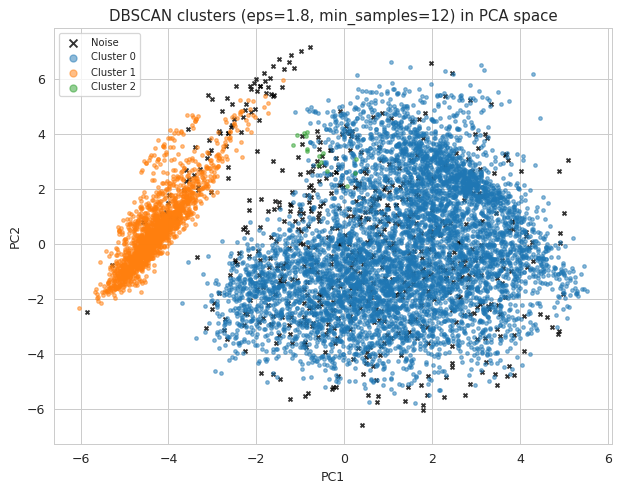

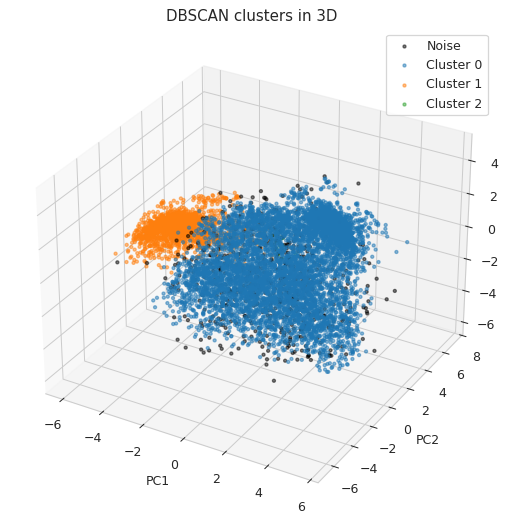

In [53]:
# Visualise the clusters in 2D (first two principal components)
def scatter2d(ax, X, labels, title):
    for lab in sorted(set(labels)):
        m = labels == lab
        ax.scatter(X[m, 0], X[m, 1], s=8 if lab != -1 else 10, alpha=0.5 if lab != -1 else 0.8,
                   c="black" if lab == -1 else None, marker="x" if lab == -1 else "o",
                   label="Noise" if lab == -1 else f"Cluster {lab}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title); ax.legend(markerscale=2, fontsize=8)

fig, ax = plt.subplots(figsize=(8, 6))
scatter2d(ax, X_pca, db_labels, f"DBSCAN clusters (eps={EPS}, min_samples={MIN_SAMPLES}) in PCA space")
plt.show()

# 3D view with PC1-PC3
fig = plt.figure(figsize=(9, 7)); ax3 = fig.add_subplot(111, projection="3d")
for lab in sorted(set(db_labels)):
    m = db_labels == lab
    ax3.scatter(X_pca[m, 0], X_pca[m, 1], X_pca[m, 2], s=6, alpha=0.5, c="black" if lab == -1 else None,
                label="Noise" if lab == -1 else f"Cluster {lab}")
ax3.set_xlabel("PC1"); ax3.set_ylabel("PC2"); ax3.set_zlabel("PC3"); ax3.legend(); ax3.set_title("DBSCAN clusters in 3D")
plt.show()


Visualize clusters in higher dimensions: Use techniques like t-SNE or UMAP to reduce the dimensionality of the data to 2D or 3D for visualization.

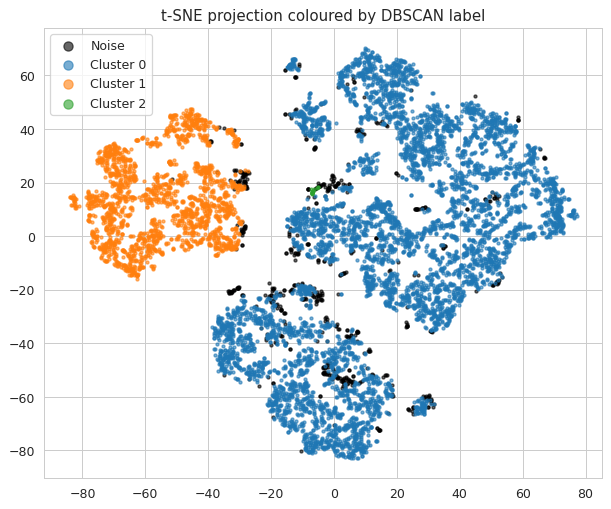

In [54]:
# Higher-dimensional view with t-SNE (UMAP is not installed by default, t-SNE gives the same kind of picture)
tsne = TSNE(n_components=2, perplexity=40, init="pca", learning_rate="auto", random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_pca)
fig, ax = plt.subplots(figsize=(8, 6.5))
for lab in sorted(set(db_labels)):
    m = db_labels == lab
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1], s=6, alpha=0.6, c="black" if lab == -1 else None,
               label="Noise" if lab == -1 else f"Cluster {lab}")
ax.set_title("t-SNE projection coloured by DBSCAN label"); ax.legend(markerscale=3); plt.show()

Visualize cluster density: Create a density plot or heatmap to show the distribution of data points within each cluster and identify areas with high or low density.

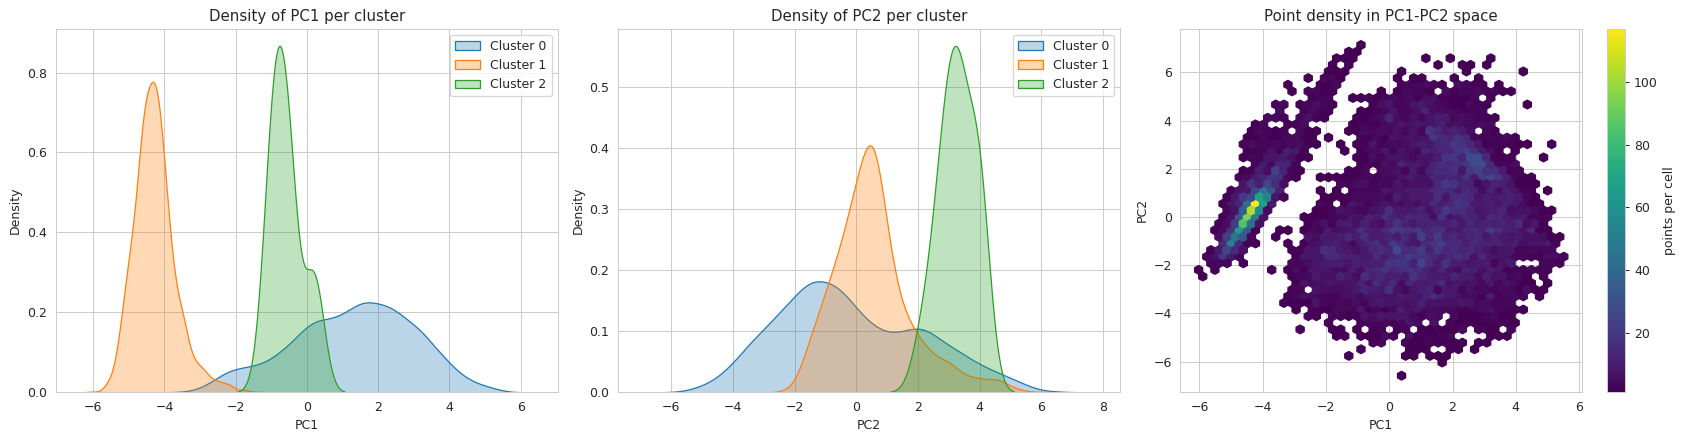

In [55]:
# Cluster density: KDE per cluster and a density heatmap
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for lab in sorted(set(db_labels) - {-1}):
    sns.kdeplot(X_pca[db_labels == lab, 0], ax=axes[0], fill=True, alpha=0.3, label=f"Cluster {lab}")
axes[0].set_title("Density of PC1 per cluster"); axes[0].set_xlabel("PC1"); axes[0].legend()
for lab in sorted(set(db_labels) - {-1}):
    sns.kdeplot(X_pca[db_labels == lab, 1], ax=axes[1], fill=True, alpha=0.3, label=f"Cluster {lab}")
axes[1].set_title("Density of PC2 per cluster"); axes[1].set_xlabel("PC2"); axes[1].legend()
hb = axes[2].hexbin(X_pca[:, 0], X_pca[:, 1], gridsize=45, cmap="viridis", mincnt=1)
plt.colorbar(hb, ax=axes[2], label="points per cell"); axes[2].set_title("Point density in PC1-PC2 space")
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
plt.tight_layout(); plt.show()

Visualize outliers: Identify and visualize outliers as points that are not assigned to any cluster.

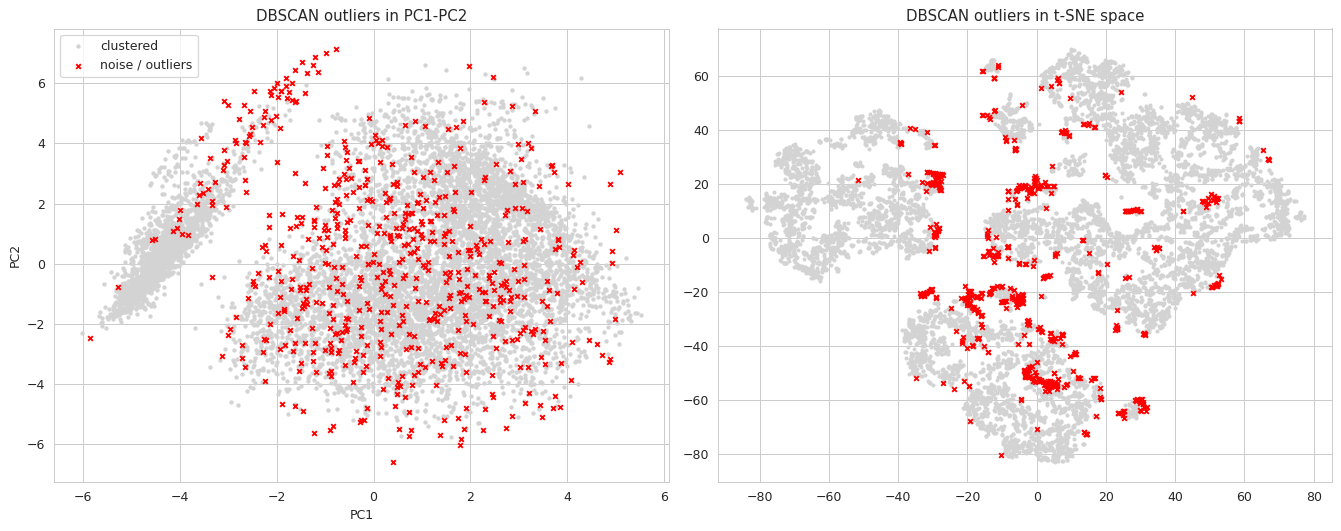

                  noise (mean)  clustered (mean)  ratio
BALANCE                1709.08           1529.02   1.12
PURCHASES              1534.24            893.41   1.72
CASH_ADVANCE           1796.95            874.27   2.06
CREDIT_LIMIT           6666.23           4317.31   1.54
PAYMENTS               3966.22           1483.54   2.67
PRC_FULL_PAYMENT          0.21              0.15   1.39


In [56]:
# Outliers = noise points (label -1)
noise_mask = db_labels == -1
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(X_pca[~noise_mask, 0], X_pca[~noise_mask, 1], s=6, c="lightgrey", label="clustered")
axes[0].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], s=14, c="red", marker="x", label="noise / outliers")
axes[0].set_title("DBSCAN outliers in PC1-PC2"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()
axes[1].scatter(X_tsne[~noise_mask, 0], X_tsne[~noise_mask, 1], s=5, c="lightgrey")
axes[1].scatter(X_tsne[noise_mask, 0], X_tsne[noise_mask, 1], s=14, c="red", marker="x")
axes[1].set_title("DBSCAN outliers in t-SNE space"); plt.tight_layout(); plt.show()

prof_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT"]
cmp = pd.DataFrame({"noise (mean)": df_clean.loc[noise_mask, prof_cols].mean(),
                    "clustered (mean)": df_clean.loc[~noise_mask, prof_cols].mean()})
cmp["ratio"] = cmp["noise (mean)"] / cmp["clustered (mean)"]
print(cmp.round(2))

## Other Clustering Techniques

### Hierarchical Clustering:

Choose a linkage method: Select an appropriate linkage method (e.g., single, complete, average, centroid) based on the desired cluster properties.

In [57]:
# Hierarchical clustering: choose the linkage method
# Compare linkage methods with the cophenetic correlation (how faithfully the tree keeps the real distances)
from scipy.spatial.distance import pdist
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_pca), 2000, replace=False)
d_sample = pdist(X_pca[idx])
for method in ["single", "complete", "average", "centroid", "ward"]:
    Z_tmp = sch.linkage(X_pca[idx], method=method)
    coph, _ = sch.cophenet(Z_tmp, d_sample)
    print(f"{method:9s} cophenetic correlation = {coph:.3f}")
# Cophenetic correlation alone would favour "average", so also look at how balanced the resulting clusters are
for method in ["single", "average", "ward"]:
    sizes = np.bincount(sch.fcluster(sch.linkage(X_pca, method=method), t=5, criterion="maxclust"))[1:]
    print(f"{method:8s} cluster sizes for k=5: {sorted(sizes.tolist(), reverse=True)}")
print("\nSingle/average linkage chain most customers into one giant cluster (useless for segmentation).")
print("Ward linkage is chosen: it minimises within-cluster variance and gives compact, balanced clusters.")
LINKAGE = "ward"

single    cophenetic correlation = 0.576


complete  cophenetic correlation = 0.520


average   cophenetic correlation = 0.696


centroid  cophenetic correlation = 0.684


ward      cophenetic correlation = 0.581


single   cluster sizes for k=5: [8945, 2, 1, 1, 1]


average  cluster sizes for k=5: [6799, 2044, 78, 27, 2]


ward     cluster sizes for k=5: [2303, 2120, 2043, 1834, 650]

Single/average linkage chain most customers into one giant cluster (useless for segmentation).
Ward linkage is chosen: it minimises within-cluster variance and gives compact, balanced clusters.


Construct the dendrogram: Create a dendrogram to visualize the hierarchical structure of the clusters.

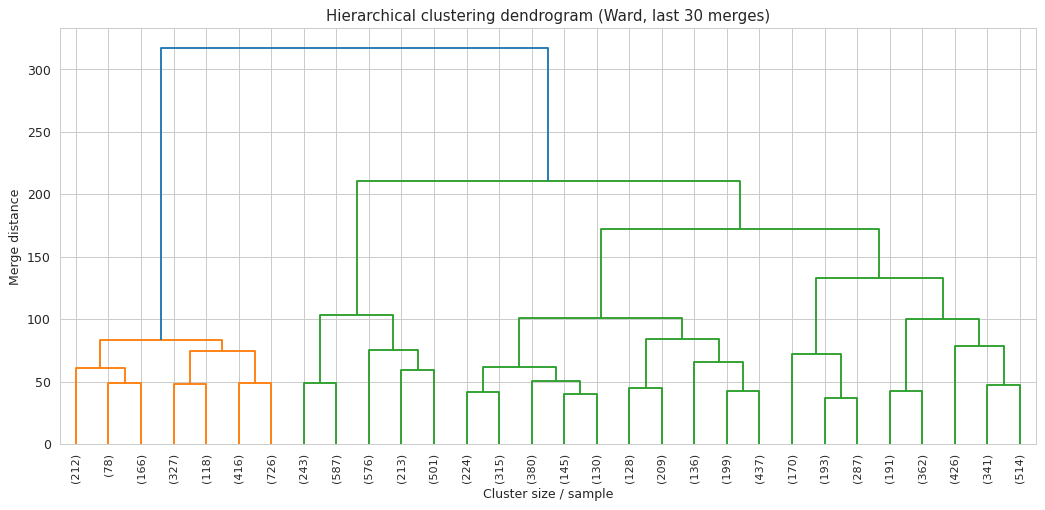

In [58]:
# Dendrogram
Z = sch.linkage(X_pca, method=LINKAGE)
plt.figure(figsize=(14, 6))
sch.dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True, leaf_rotation=90, leaf_font_size=9)
plt.title("Hierarchical clustering dendrogram (Ward, last 30 merges)")
plt.xlabel("Cluster size / sample"); plt.ylabel("Merge distance"); plt.show()

Determine the number of clusters: Decide on the number of clusters based on the dendrogram or using a cutoff value for the distance between clusters.

In [59]:
# Decide the number of clusters
# Look at the biggest jumps in merge distance and compare silhouette scores for k = 2..8
last = Z[-10:, 2][::-1]
print("Last 10 merge distances:", np.round(last, 1))
print("Jump sizes:", np.round(-np.diff(last), 1))
hc_sil = {}
for k in range(2, 9):
    lab_k = sch.fcluster(Z, t=k, criterion="maxclust")
    hc_sil[k] = silhouette_score(X_pca, lab_k, sample_size=4000, random_state=RANDOM_STATE)
print("\nSilhouette by k:", {k: round(v, 3) for k, v in hc_sil.items()})
K_HC = max((k for k in hc_sil if k >= 3), key=hc_sil.get)     # >= 3 so that we get real segments
cut_height = (Z[-(K_HC - 1), 2] + Z[-K_HC, 2]) / 2
print(f"\nChosen number of clusters: {K_HC}  (dendrogram cut at distance ~ {cut_height:.1f})")

Last 10 merge distances: [317.  210.5 172.4 133.3 103.7 100.8 100.   84.4  83.4  78.7]
Jump sizes: [106.5  38.1  39.1  29.7   2.9   0.8  15.6   1.    4.6]



Silhouette by k: {2: 0.285, 3: 0.226, 4: 0.239, 5: 0.24, 6: 0.201, 7: 0.206, 8: 0.208}

Chosen number of clusters: 5  (dendrogram cut at distance ~ 118.5)


Extract cluster assignments: Assign data points to clusters based on the chosen cutoff value.

In [60]:
# Extract the cluster assignments
hc_labels = sch.fcluster(Z, t=K_HC, criterion="maxclust") - 1      # 0..K-1
print(pd.Series(hc_labels).value_counts().sort_index().rename("n_customers"))
# cross-check with scikit-learn
agg_labels = AgglomerativeClustering(n_clusters=K_HC, linkage="ward").fit_predict(X_pca)
print("\nAgreement with sklearn AgglomerativeClustering (ARI):", round(adjusted_rand_score(hc_labels, agg_labels), 3))

0    2043
1    2120
2    2303
3     650
4    1834
Name: n_customers, dtype: int64



Agreement with sklearn AgglomerativeClustering (ARI): 1.0


Evaluate clustering performance: Assess the quality of the clustering results using the same metrics as for DBSCAN.

In [61]:
# Evaluate hierarchical clustering (same metrics as DBSCAN)
hc_scores = evaluate(X_pca, hc_labels, f"Hierarchical (Ward, k={K_HC})")
print(pd.Series({k: v for k, v in hc_scores.items() if k != "algorithm"}).round(3))

silhouette              0.234
calinski_harabasz    2158.492
davies_bouldin          1.617
dtype: float64


### Non-Hierarchical Clustering (K-means)

Choose the number of clusters: Determine the optimal number of clusters using techniques like the elbow method or silhouette analysis.

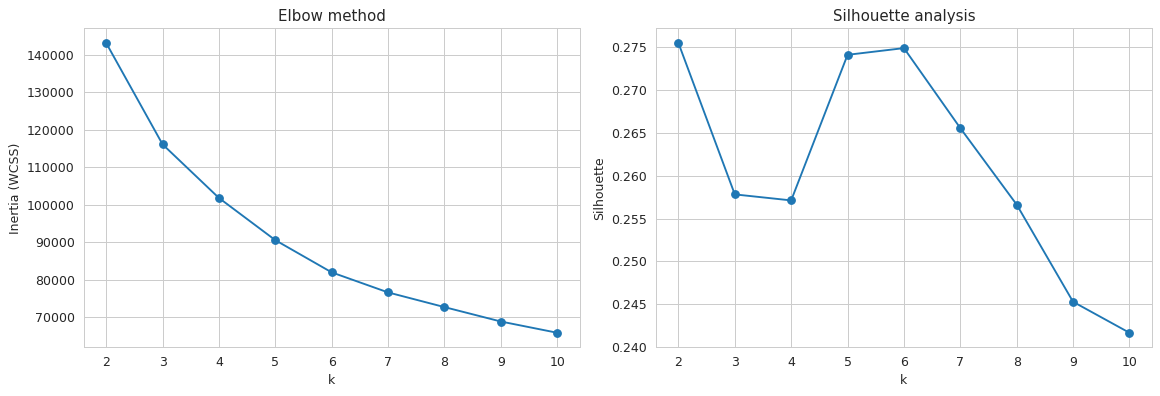

{2: 0.275, 3: 0.258, 4: 0.257, 5: 0.274, 6: 0.275, 7: 0.266, 8: 0.257, 9: 0.245, 10: 0.242}
Chosen k (best silhouette with k >= 3): 6


In [62]:
# K-means: choose k with the elbow method and silhouette analysis
inertias, sils = [], []
ks = range(2, 11)
for k in ks:
    km_tmp = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_pca)
    inertias.append(km_tmp.inertia_)
    sils.append(silhouette_score(X_pca, km_tmp.labels_, sample_size=4000, random_state=RANDOM_STATE))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ks, inertias, "o-"); axes[0].set_title("Elbow method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (WCSS)")
axes[1].plot(ks, sils, "o-"); axes[1].set_title("Silhouette analysis"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()
print({k: round(s, 3) for k, s in zip(ks, sils)})
K_KM = max((k for k, s in zip(ks, sils) if k >= 3), key=lambda k: sils[list(ks).index(k)])
print("Chosen k (best silhouette with k >= 3):", K_KM)

Initialize cluster centroids: Randomly select initial cluster centroids.

In [63]:
# K-means from scratch (steps 1-4 of Lloyd's algorithm). Step 1: initialise centroids randomly
rng = np.random.RandomState(RANDOM_STATE)
init_idx = rng.choice(len(X_pca), K_KM, replace=False)
centroids = X_pca[init_idx].copy()
print("Initial centroids (first 3 dims):")
print(np.round(centroids[:, :3], 2))

Initial centroids (first 3 dims):
[[-1.41  2.7  -2.69]
 [ 0.24 -1.47 -0.29]
 [ 2.15  1.3   2.57]
 [ 1.44 -2.4  -1.47]
 [ 3.32 -1.57 -0.27]
 [ 1.39  2.83  1.52]]


Assign data points to clusters: Assign each data point to the nearest cluster centroid.

In [64]:
# Step 2: assign every point to its nearest centroid
def assign_clusters(X, centroids):
    dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)   # (n_points, k)
    return dists.argmin(axis=1)

km_labels_0 = assign_clusters(X_pca, centroids)
print("Cluster sizes after the first assignment:", np.bincount(km_labels_0, minlength=K_KM))

Cluster sizes after the first assignment: [1664 2827 1318  891 1195 1055]


Recompute cluster centroids: Calculate the new centroids for each cluster based on the assigned data points.

In [65]:
# Step 3: recompute each centroid as the mean of its assigned points
def update_centroids(X, labels, k, old):
    new = old.copy()
    for j in range(k):
        if (labels == j).any():            # keep the old centroid if a cluster becomes empty
            new[j] = X[labels == j].mean(axis=0)
    return new

new_centroids = update_centroids(X_pca, km_labels_0, K_KM, centroids)
print("Centroid movement after the first update:", np.round(np.linalg.norm(new_centroids - centroids, axis=1), 3))

Centroid movement after the first update: [2.697 2.744 1.064 2.107 1.471 1.156]


Iterate until convergence: Repeat previous 2 steps until the cluster assignments stabilize or a maximum number of iterations is reached.

Converged after 51 iterations (WCSS = 82012.0)


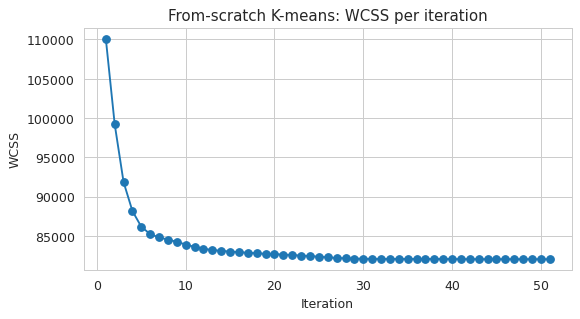

Manual vs sklearn K-means agreement (ARI): 0.996
0     851
1    1960
2    1638
3    1692
4    1319
5    1490
Name: n_customers, dtype: int64


In [66]:
# Step 4: iterate until the centroids stop moving (or max iterations)
centroids = X_pca[init_idx].copy()
history = []
for it in range(1, 301):
    labels_it = assign_clusters(X_pca, centroids)
    new_centroids = update_centroids(X_pca, labels_it, K_KM, centroids)
    shift = np.linalg.norm(new_centroids - centroids)
    wcss = ((X_pca - new_centroids[labels_it]) ** 2).sum()
    history.append((it, shift, wcss))
    centroids = new_centroids
    if shift < 1e-6:
        break
km_manual_labels = assign_clusters(X_pca, centroids)
print(f"Converged after {it} iterations (WCSS = {history[-1][2]:.1f})")
plt.figure(figsize=(7, 3.5)); plt.plot([h[0] for h in history], [h[2] for h in history], "o-")
plt.xlabel("Iteration"); plt.ylabel("WCSS"); plt.title("From-scratch K-means: WCSS per iteration"); plt.show()

# Final model used in the rest of the notebook: scikit-learn K-means (k-means++ init, 10 restarts - more robust)
kmeans = KMeans(n_clusters=K_KM, n_init=10, random_state=RANDOM_STATE).fit(X_pca)
km_labels = kmeans.labels_
print("Manual vs sklearn K-means agreement (ARI):", round(adjusted_rand_score(km_manual_labels, km_labels), 3))
print(pd.Series(km_labels).value_counts().sort_index().rename("n_customers"))

Visualize cluster assignments: Plot the data points with different colors or markers to represent the cluster assignments from each clustering algorithm.

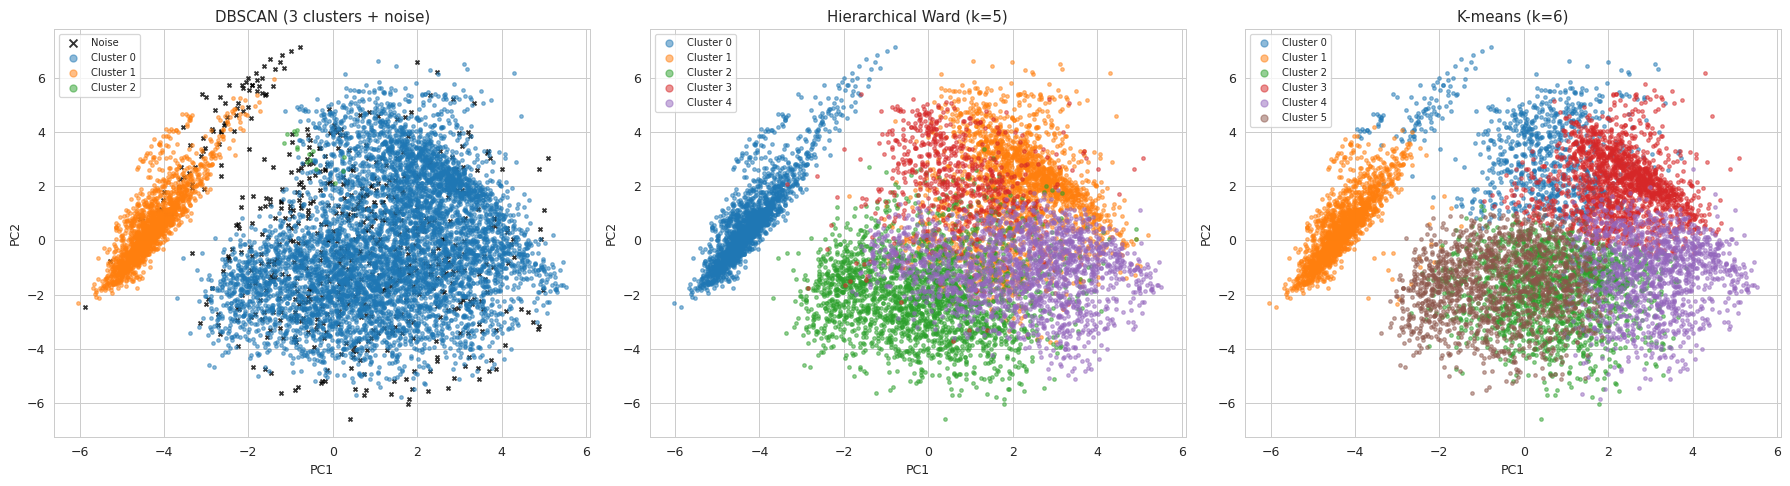

In [67]:
# Visualise the assignments of all three algorithms in the same PCA space
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
scatter2d(axes[0], X_pca, db_labels, f"DBSCAN ({n_clusters_db} clusters + noise)")
scatter2d(axes[1], X_pca, hc_labels, f"Hierarchical Ward (k={K_HC})")
scatter2d(axes[2], X_pca, km_labels, f"K-means (k={K_KM})")
plt.tight_layout(); plt.show()

Compare clustering results: Analyze the similarities and differences between the clusters obtained from hierarchical, non-hierarchical, and DBSCAN.

In [68]:
# Compare the clustering results
labels_all = {"DBSCAN": db_labels, "Hierarchical": hc_labels, "K-means": km_labels}
names = list(labels_all)
ari = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        ari.loc[a, b] = adjusted_rand_score(labels_all[a], labels_all[b])
print("Adjusted Rand Index between algorithms (1 = identical partition):")
print(ari.round(3))

print("\nHierarchical vs K-means:")
print(pd.crosstab(pd.Series(hc_labels, name="Hierarchical"), pd.Series(km_labels, name="K-means")))
print("\nDBSCAN vs K-means (-1 = DBSCAN noise):")
print(pd.crosstab(pd.Series(db_labels, name="DBSCAN"), pd.Series(km_labels, name="K-means")))

# What do the K-means segments mean in business terms?
seg = df_clean[["BALANCE","PURCHASES","CASH_ADVANCE","CREDIT_LIMIT","PAYMENTS","PURCHASES_FREQUENCY","PRC_FULL_PAYMENT"]].copy()
seg["K-means segment"] = km_labels
print("\nK-means segment profiles (means):")
print(seg.groupby("K-means segment").mean().round(2).assign(size=pd.Series(km_labels).value_counts().sort_index()))

Adjusted Rand Index between algorithms (1 = identical partition):
              DBSCAN  Hierarchical  K-means
DBSCAN         1.000         0.275    0.214
Hierarchical   0.275         1.000    0.515
K-means        0.214         0.515    1.000

Hierarchical vs K-means:
K-means         0     1     2     3    4    5
Hierarchical                                 
0             102  1941     0     0    0    0
1             178     1   381  1489   66    5
2              43    18  1027    67  216  932
3             516     0     6    23   44   61
4              12     0   224   113  993  492

DBSCAN vs K-means (-1 = DBSCAN noise):
K-means    0     1     2     3     4     5
DBSCAN                                    
-1       175    35   112    45   109   122
 0       602    10  1526  1647  1210  1368
 1        59  1915     0     0     0     0
 2        15     0     0     0     0     0

K-means segment profiles (means):
                 BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  PU

Evaluate clustering performance: Compare the clustering performance metrics (e.g., silhouette coefficient, Calinski-Harabasz index) for each algorithm.

                          silhouette  calinski_harabasz  davies_bouldin  n_clusters  noise_%
algorithm                                                                                   
DBSCAN                         0.265           1687.134           1.021           3    6.682
Hierarchical (Ward, k=5)       0.234           2158.492           1.617           5    0.000
K-means (k=6)                  0.272           2481.334           1.414           6    0.000


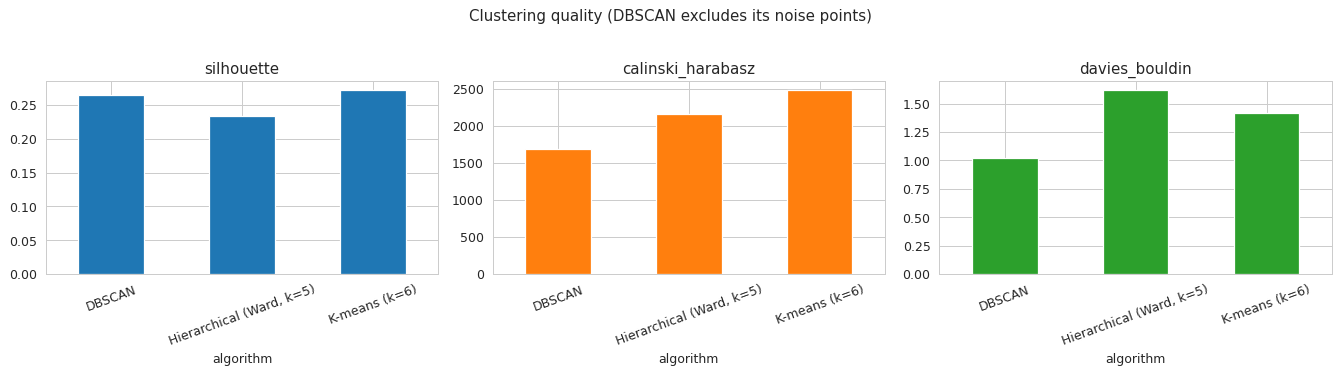

In [69]:
# Performance metrics side by side
results = pd.DataFrame([db_scores, hc_scores, evaluate(X_pca, km_labels, f"K-means (k={K_KM})")]).set_index("algorithm")
results["n_clusters"] = [n_clusters_db, K_HC, K_KM]
results["noise_%"] = [100 * (db_labels == -1).mean(), 0.0, 0.0]
print(results.round(3))
results[["silhouette", "calinski_harabasz", "davies_bouldin"]].plot(kind="bar", subplots=True, layout=(1, 3), figsize=(15, 4), legend=False, rot=20)
plt.suptitle("Clustering quality (DBSCAN excludes its noise points)", y=1.03); plt.tight_layout(); plt.show()

Identify strengths and weaknesses: Determine the strengths and weaknesses of each clustering algorithm based on the results and the characteristics of the data.

**Strengths and weaknesses (based on the results above)**

| Algorithm | Strengths | Weaknesses |
|---|---|---|
| **DBSCAN** | Needs no preset number of clusters; flags unusual customers as noise (6.7% here: on average about 2.1x the cash advances and 2.7x the payments of clustered customers); finds the "no-purchase" group (cluster 1, 1,974 customers) cleanly. | Very sensitive to `eps`/`min_samples` (the grid showed results jumping between 2 and 49 clusters); the data has no clear density gaps, so it lumps 71% of customers into one big cluster and creates a 15-customer cluster; weaker in higher dimensions. |
| **Hierarchical (Ward)** | Gives a full dendrogram, so the user can choose the number of clusters at different levels; deterministic; no random start. | Lowest silhouette (0.234) and worst Davies-Bouldin (1.617); cost grows quadratically (it needs an 8,950 x 8,950 distance structure); a merge can never be undone. |
| **K-means** | Highest silhouette (0.272) and Calinski-Harabasz (2,481); fast; every customer gets a segment; segments are easy to profile (e.g. inactive cash-advance users, big-spend full payers, low-activity users). | Needs `k` up front (silhouette is almost flat between k = 2 and 8, so k = 6 is a judgement call); assumes round, similar-sized clusters; sensitive to outliers; no noise concept. |

Choose the best algorithm: Select the clustering algorithm that provides the most meaningful and accurate results for the specific problem.

**Best algorithm for this problem: K-means (k = 6), with DBSCAN as a complementary outlier detector.**

* K-means has the best silhouette (0.272, slightly above DBSCAN's 0.265, which is measured only after discarding its 6.7% noise points) and the best Calinski-Harabasz score (2,481 vs 1,687 for DBSCAN). DBSCAN does win on Davies-Bouldin (1.02 vs 1.41), but that is largely because most of its points sit in one huge cluster.
* It assigns every customer to a segment with a clear business meaning, which is the goal of credit-card segmentation (marketing offers, credit-limit decisions, risk monitoring). Its segments are also well separated in terms of behaviour, e.g. segment 1 = customers who never purchase but use cash advances (about 22% of customers) and segment 4 = high spenders with high limits who pay in full more often than most other segments.
* DBSCAN is not a good segmentation tool on this data because the density is continuous: it produced one cluster with 71% of the customers, one with 22%, and one with only 15. Still, its noise label is useful: the 598 flagged customers pay and borrow far more than average and deserve a closer look.
* Caveat: all silhouette scores are low (about 0.2-0.3), so the segments overlap and should be treated as behavioural tendencies, not hard boundaries.